# 🔧 Notebook-06: LLM Training & Fine-tuning
**KI Advanced · IA1017000 · Polizei Baden-Württemberg · Institut für Fortbildung**

---

| | |
|---|---|
| **Session** | S 2.3 – LLM Training & Fine-tuning |
| **Dauer** | ~35 Minuten |
| **Format** | Vollständige Pipeline – konzeptionell + praktisch |
| **Hardware** | NVIDIA DGX Spark (Training vorab) · RTX 4090 / Colab (Demo) |

---

### 🗺️ Was wir heute durchlaufen

```
KONZEPT          DATEN            TRAINING          LIVE-DEMO
   │                │                 │                  │
Wie entsteht     Unsere          Fine-tuning       Basis-Modell
ein LLM?      Datensätze         auf DGX          vs. trainiert
LoRA erklären   prüfen &         Spark —          → der Unter-
Entscheidung:   aufbereiten     auskommentiert,    schied ist
Prompting /                     aber vollständig   sichtbar!
RAG / FT?                       gezeigt
```

---

> ### 📌 Hinweis zur Session
>
> Das Training selbst wurde **vor dem Seminar** auf dem DGX Spark durchgeführt (~5h).  
> Der fertige LoRA-Adapter liegt bereit.  
> Alle Trainings-Zellen sind **auskommentiert und mit** `⏸ NICHT AUSFÜHREN` **markiert** —  
> wir lesen und verstehen den Code gemeinsam, führen ihn aber nicht aus.  
> Alle anderen Zellen laufen **sofort** (`▶ AUSFÜHREN`).

---

## ⚙️ Setup – Bibliotheken laden

Kurz ausführen — läuft in Sekunden.

> 💡 **Was geladen wird:**  
> `numpy` – Mathematik · `matplotlib` – Grafiken · `warnings` – Warnmeldungen unterdrücken


In [1]:
# ── Bibliotheken laden ───────────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch
import warnings; warnings.filterwarnings('ignore')

# ── Farbpalette (Polizei BW) ──────────────────────────────────────────────────
C = {
    'navy':   '#001E46',
    'blue1':  '#0D3761',
    'blue2':  '#1A4E8A',
    'ice':    '#4FC3F7',
    'orange': '#ED7D31',
    'green':  '#52B788',
    'teal':   '#00B4D8',
    'lgray':  '#B0C4DE',
    'white':  '#FFFFFF',
    'purple': '#9B59B6',
    'gold':   '#FFC300',
    'red':    '#E74C3C',
}

plt.style.use('dark_background')
plt.rcParams.update({
    'figure.facecolor': C['navy'],
    'axes.facecolor':   C['blue1'],
    'axes.edgecolor':   C['lgray'],
    'axes.labelcolor':  C['lgray'],
    'xtick.color':      C['lgray'],
    'ytick.color':      C['lgray'],
    'text.color':       C['white'],
    'grid.color':       C['blue2'],
    'grid.alpha':       0.4,
    'font.size':        11,
})

print('✅ Setup OK')


✅ Setup OK


---

## 🧠 Teil 1 – Wie entsteht ein LLM? Die drei Phasen

Bevor wir Fine-tuning verstehen, brauchen wir das konzeptionelle Fundament.  
Ein produktionsreifes LLM entsteht in **drei aufeinander aufbauenden Phasen** —  
und nur eine davon ist für Behörden wirklich relevant.

---

### Phase 1: Pre-training – „Die Universität"

> Das Modell liest das gesamte verfügbare Wissen der Menschheit.

- **Was passiert:** Das Modell sieht **Billionen von Token** — Internet, Bücher, Wikipedia, Code
- **Aufgabe:** Immer das nächste Token vorhersagen *(das haben wir in NB-05 verstanden)*
- **Dauer:** Wochen bis Monate auf tausenden GPUs
- **Kosten:** GPT-3: ~4,6 Mio. USD · GPT-4: geschätzt >100 Mio. USD
- **Ergebnis:** Ein „Basis-Modell" das Sprache versteht — aber noch kein Assistent ist

> 🏥 **Analogie:** Ein Medizinstudent, der sechs Jahre lang jeden verfügbaren Text liest.

---

### Phase 2: Instruction Tuning (SFT) – „Das Praktikum"

> Das Modell lernt, Anweisungen zu befolgen.

- **Was passiert:** Training auf **Instruktions-Antwort-Paaren** (Instruction Tuning)
- **Aufgabe:** `Instruction → erwünschte Antwort` lernen
- **Dauer:** Stunden bis Tage auf wenigen GPUs
- **Kosten:** Hunderte bis Tausende Euro
- **Ergebnis:** Ein Modell das Anfragen versteht und strukturiert antwortet

> 🏥 **Analogie:** Der Arzt macht Praktikum — lernt wie man mit Patienten spricht.

---

### Phase 3: Fine-tuning – „Die Spezialisierung" ← **Das ist unser Einstiegspunkt**

> Das Modell lernt eine spezifische Domäne oder einen spezifischen Stil.

- **Was passiert:** Training auf **domänenspezifischen Paaren** (z.B. Polizei-BW-Stil)
- **Aufgabe:** Das Modell soll so schreiben, wie ein erfahrener Sachbearbeiter
- **Dauer:** 2–5 Stunden (mit LoRA, auf DGX Spark)
- **Kosten:** Zentpreise (Strom)
- **Ergebnis:** Ein Assistent der im dienstlichen Polizei-Stil schreibt

> 🏥 **Analogie:** Der Arzt spezialisiert sich auf Notaufnahme — Fachsprache, Protokolle, Tempo.

---

| Phase | Wer macht das? | Kosten | Für uns relevant? |
|-------|---------------|--------|-------------------|
| Pre-training | Google, Meta, Anthropic | >100 Mio. USD | ❌ Nein |
| Instruction Tuning | Modellanbieter | Tausende USD | ❌ Nein |
| **Fine-tuning** | **Wir** | **~0,24 EUR Strom** | **✅ Ja** |


---

## 🔩 Teil 2 – Fine-tuning vs. LoRA: Was ist der Unterschied?

Bevor wir visualisieren: Der Begriff „Fine-tuning" wird oft unscharf verwendet.  
Es gibt zwei grundlegend verschiedene Methoden — mit sehr unterschiedlichen Anforderungen.

---

### Methode A: Full Fine-tuning — alle Parameter werden verändert

```
Basis-Modell (Llama 3.1 8B):   8.000.000.000 Parameter
                                        ↓
         ALLE Parameter werden mit neuen Daten neu trainiert
                                        ↓
Finetuned Model:                8.000.000.000 Parameter (verändert)
```

**Was das bedeutet:**
- ✅ Maximale Anpassungsfähigkeit — das Modell kann tiefgreifend verändert werden
- ❌ ~80 GB VRAM nötig
- ❌ Cloud-Kosten: 500–2.000 USD
- ❌ Das ursprüngliche Basismodell ist verloren — Dateigröße: ~16 GB
- ❌ Ein Modell pro Aufgabe — kein Wiederverwenden

**VRAM-Bedarf Full Fine-tuning je Modellgröße:**

| Modell | Parameter | VRAM min. | VRAM empfohlen |
|--------|-----------|-----------|----------------|
| Llama 3.2 1B | 1 Mrd. | ~12 GB | ~14 GB |
| Llama 3.2 3B | 3 Mrd. | ~36 GB | ~43 GB |
| **Llama 3.1 8B** | **8 Mrd.** | **~96 GB** | **~115 GB** |
| Llama 3.1 13B | 13 Mrd. | ~156 GB | ~187 GB |
| Llama 3.1 70B | 70 Mrd. | ~840 GB | ~1.008 GB |
| Llama 3.1 405B | 405 Mrd. | ~4.860 GB | ~5.800 GB |

> **Faustformel:** VRAM (GB) ≈ Milliarden Parameter × 18–20  
> Setzt sich zusammen aus: Modellgewichte (BF16, 2 B/Param) + Gradienten (2 B/Param)  
> + AdamW-Optimizer (8 B/Param für m und v) + Aktivierungen (~20% Overhead).
>
> **Zum Vergleich — unser DGX Spark (128 GB):**  
> Full FT von Llama 8B = 115 GB → passt knapp, aber kein Spielraum für Batch > 1.  
> Mit LoRA (rank=32) = ~8 GB → 16× Batch möglich, Faktor 5× schneller.


---

### Methode B: LoRA — nur winzige Zusatz-Matrizen werden trainiert

**LoRA (Low-Rank Adaptation)** friert das Basis-Modell vollständig ein  
und hängt zwei kleine trainierbare Matrizen (A und B) an bestimmte Schichten:

```
Basis-Modell (Llama 3.1 8B):   8.000.000.000 Parameter  ← EINGEFROREN ❄️
                                        +
LoRA-Adapter:                      33.500.000 Parameter  ← WIRD TRAINIERT ✏️
                                        ↓
Beim Laden:   W_aktiv = W_basis + A · B
```

**Was das bedeutet:**
- ✅ ~8 GB VRAM reichen (RTX 4090, DGX Spark)
- ✅ Kosten: Cent-Bereich (Strom)
- ✅ Basis-Modell bleibt unverändert — mehrere Adapter parallel möglich
- ✅ Adapter: nur ~50 MB — statt 16 GB eines Full Fine-tuned Modells
- ✅ Qualitätsverlust gegenüber Full FT: oft < 3%

---

### Der entscheidende Unterschied

| | **Full Fine-tuning** | **LoRA** |
|---|---|---|
| **Was wird trainiert?** | Alle 8 Mrd. Parameter | ~33 Mio. Adapter-Parameter (0,4%) |
| **Basis-Modell danach** | Verändert, nicht mehr trennbar | Unberührt — bleibt identisch |
| **VRAM** | ~80 GB | ~8 GB |
| **Kosten** | 500–2.000 USD | <1 EUR Strom |
| **Dateigröße** | ~16 GB | ~50 MB Adapter |
| **Adapter pro Aufgabe** | 1 Modell = 1 Aufgabe | 1 Basis + N × 50 MB Adapter |
| **Produktionsreife** | Sehr hoch | Nahezu gleichwertig |

> **Full Fine-tuning ist technisch interessant — aber praktisch irrelevant,  
> solange kein GPU-Cluster zur Verfügung steht**.

---

### Warum funktioniert LoRA überhaupt?

Die Intuition: Wenn ein bereits gut trainiertes Modell für eine neue Aufgabe  
angepasst wird, sind die nötigen Gewichtsänderungen typischerweise  
**niedrig-dimensional** — sie lassen sich durch zwei kleine Matrizen approximieren.

```
Mathematisch:  W_neu = W_alt + ΔW  ≈  W_alt + A · B

  d = 4096  (Modelldimension, z.B. Llama 7B)
  rank = 16 (LoRA-Rank, frei wählbar)

  ΔW hätte  d × d = 16.777.216 Parameter  →  Full FT
  A · B hat  2 × d × rank = 131.072 Parameter  →  LoRA  (128× kleiner)
```

Je höher der **Rank**, desto mehr Lernkapazität — aber auch mehr Parameter.  
Für Stil-Anpassungen reicht rank=8. Für komplexe Domänen: rank=32–64.


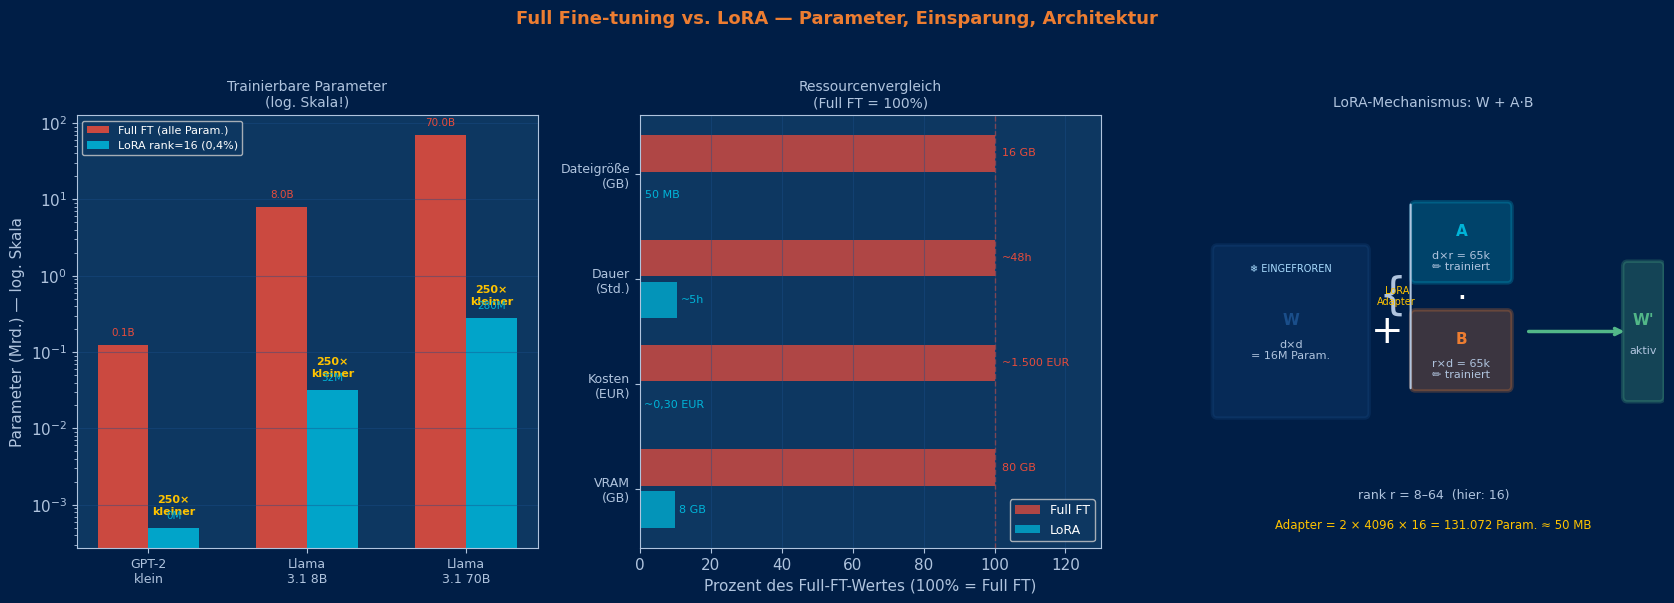


💡 Grafik links:  LOG-Skala notwendig — LoRA-Balken wäre sonst unsichtbar.
   Das zeigt das Problem anschaulich: Full FT und LoRA sind nicht
   vergleichbar auf linearer Achse. 240× Unterschied bei Llama 8B.

💡 Grafik Mitte:  Relative Kosten. LoRA braucht 10% des VRAM,
   0,02% der Kosten, 10% der Zeit, 0,3% des Speicherplatzes.

💡 Grafik rechts: W bleibt eingefroren (❄️). Nur A und B werden
   trainiert. Beim Laden werden sie addiert: W + A·B = W'.


In [2]:
# ▶ AUSFÜHREN — Full Fine-tuning vs. LoRA visualisieren

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch

fig = plt.figure(figsize=(17, 6))
fig.patch.set_facecolor(C['navy'])
fig.suptitle('Full Fine-tuning vs. LoRA — Parameter, Einsparung, Architektur',
             color=C['orange'], fontsize=13, fontweight='bold', y=1.01)

ax0 = fig.add_subplot(1, 3, 1)
ax1 = fig.add_subplot(1, 3, 2)
ax2 = fig.add_subplot(1, 3, 3)

for ax in [ax0, ax1, ax2]:
    ax.set_facecolor(C['blue1'])

# ── Grafik 1: Parameter-Vergleich (LOG-Skala — sonst unsichtbar) ──────────────
modelle   = ['GPT-2\nklein', 'Llama\n3.1 8B', 'Llama\n3.1 70B']
full_mrd  = [0.124, 8.0, 70.0]   # Milliarden Parameter
lora_mrd  = [0.124*0.004, 8.0*0.004, 70.0*0.004]  # ~0.4% bei rank=16

x = np.arange(len(modelle))
w = 0.32
b1 = ax0.bar(x - w/2, full_mrd, w, color=C['red'],  alpha=0.88, label='Full FT (alle Param.)')
b2 = ax0.bar(x + w/2, lora_mrd, w, color=C['teal'], alpha=0.88, label='LoRA rank=16 (0,4%)')

ax0.set_yscale('log')   # LOG-Skala: sonst verschwindet LoRA-Balken
ax0.set_xticks(x)
ax0.set_xticklabels(modelle, fontsize=9)
ax0.set_ylabel('Parameter (Mrd.) — log. Skala')
ax0.set_title('Trainierbare Parameter\n(log. Skala!)', color=C['lgray'], fontsize=10)
ax0.legend(fontsize=8)
ax0.grid(True, axis='y', alpha=0.4)

# Verhältniszahlen über LoRA-Balken
for xi, (f, l) in enumerate(zip(full_mrd, lora_mrd)):
    ax0.text(xi + w/2, l * 1.5, f'{f/l:.0f}×\nkleiner',
             ha='center', fontsize=8, color=C['gold'], fontweight='bold')

# Beschriftung: Absolutzahlen über jedem Balken
for xi, f in enumerate(full_mrd):
    ax0.text(xi - w/2, f * 1.3, f'{f:.1f}B', ha='center', fontsize=7.5, color=C['red'])
for xi, l in enumerate(lora_mrd):
    ax0.text(xi + w/2, l * 1.3, f'{l*1000:.0f}M', ha='center', fontsize=7.5, color=C['teal'])

# ── Grafik 2: Kosten- und Ressourcenvergleich ──────────────────────────────────
kategorien = ['VRAM\n(GB)', 'Kosten\n(EUR)', 'Dauer\n(Std.)', 'Dateigröße\n(GB)']
full_werte = [80,  1500, 48, 16]
lora_werte = [8,   0.3,  5,  0.05]

# Normiert auf Full-Wert = 100% für sichtbaren Vergleich
ax1.set_facecolor(C['blue1'])
y = np.arange(len(kategorien))

# Balken links = Full FT (rot), rechts = LoRA (teal)
bars_full = ax1.barh(y + 0.2, [100]*4, 0.35, color=C['red'],  alpha=0.75, label='Full FT')
bars_lora = ax1.barh(y - 0.2, [f/b*100 for f,b in zip(lora_werte, full_werte)], 0.35,
                     color=C['teal'], alpha=0.75, label='LoRA')

ax1.set_yticks(y)
ax1.set_yticklabels(kategorien, fontsize=9)
ax1.set_xlabel('Prozent des Full-FT-Wertes (100% = Full FT)')
ax1.set_title('Ressourcenvergleich\n(Full FT = 100%)', color=C['lgray'], fontsize=10)
ax1.axvline(100, color=C['red'], lw=1, ls='--', alpha=0.5)
ax1.set_xlim(0, 130)
ax1.legend(fontsize=9)
ax1.grid(True, axis='x', alpha=0.4)

# Absolute Werte als Label
labels_full = ['80 GB', '~1.500 EUR', '~48h', '16 GB']
labels_lora = ['8 GB', '~0,30 EUR', '~5h', '50 MB']
for i, (lf, ll, lw) in enumerate(zip(labels_full, labels_lora, lora_werte)):
    ax1.text(102, i + 0.2, lf,  va='center', fontsize=8, color=C['red'])
    pct = lw/full_werte[i]*100
    ax1.text(pct + 1, i - 0.2, ll, va='center', fontsize=8, color=C['teal'])

# ── Grafik 3: LoRA-Architektur W = W + A·B ────────────────────────────────────
ax2.set_xlim(0, 10)
ax2.set_ylim(0, 8)
ax2.axis('off')
ax2.set_title('LoRA-Mechanismus: W + A·B', color=C['lgray'], fontsize=10)

def box(ax, x, y, w, h, col, label, sub='', frozen=False):
    ax.add_patch(FancyBboxPatch((x, y), w, h, boxstyle='round,pad=0.1',
                                facecolor=col, alpha=0.25, edgecolor=col, lw=2.5))
    ax.text(x+w/2, y+h/2+(0.2 if sub else 0), label,
            ha='center', va='center', fontsize=11, fontweight='bold', color=col)
    if sub:
        ax.text(x+w/2, y+h/2-0.35, sub,
                ha='center', va='center', fontsize=8, color=C['lgray'])
    if frozen:
        ax.text(x+w/2, y+h-0.25, '❄️ EINGEFROREN',
                ha='center', va='top', fontsize=7, color='#aaddff')

# W (eingefroren)
box(ax2, 0.3, 2.5, 3.2, 3.0, C['blue2'], 'W', f'd×d\n= 16M Param.', frozen=True)

# Plus-Zeichen
ax2.text(4.0, 4.0, '+', ha='center', va='center', fontsize=28, color=C['white'])

# A und B (trainiert)
box(ax2, 4.6, 5.0, 2.0, 1.3, C['teal'],   'A', f'd×r = 65k\n✏️ trainiert')
ax2.text(5.6, 4.6, '·', ha='center', va='center', fontsize=24, color=C['white'])
box(ax2, 4.6, 3.0, 2.0, 1.3, C['orange'], 'B', f'r×d = 65k\n✏️ trainiert')

# Klammer um A und B
ax2.annotate('', xy=(4.5, 2.9), xytext=(4.5, 6.4),
             arrowprops=dict(arrowstyle='-', color=C['lgray'], lw=1.5,
                             connectionstyle='arc3,rad=0'))
ax2.text(4.1, 4.65, '{', ha='center', va='center', fontsize=32, color=C['lgray'])
ax2.text(4.2, 4.65, 'LoRA\nAdapter',
         ha='center', va='center', fontsize=7, color=C['gold'])

# Pfeil zum Ergebnis
ax2.annotate('', xy=(9.2, 4.0), xytext=(7.0, 4.0),
             arrowprops=dict(arrowstyle='->', color=C['green'], lw=2.5))

# W' (Ergebnis)
box(ax2, 9.2, 2.8, 0.7, 2.4, C['green'], "W'", 'aktiv')

# Beschriftungen unten
ax2.text(5.0, 0.9, f'rank r = 8–64  (hier: 16)',
         ha='center', fontsize=9, color=C['lgray'])
ax2.text(5.0, 0.35, f'Adapter = 2 × 4096 × 16 = 131.072 Param. ≈ 50 MB',
         ha='center', fontsize=8.5, color=C['gold'])

plt.tight_layout(pad=1.5)
plt.show()

print()
print('💡 Grafik links:  LOG-Skala notwendig — LoRA-Balken wäre sonst unsichtbar.')
print('   Das zeigt das Problem anschaulich: Full FT und LoRA sind nicht')
print('   vergleichbar auf linearer Achse. 240× Unterschied bei Llama 8B.')
print()
print('💡 Grafik Mitte:  Relative Kosten. LoRA braucht 10% des VRAM,')
print('   0,02% der Kosten, 10% der Zeit, 0,3% des Speicherplatzes.')
print()
print('💡 Grafik rechts: W bleibt eingefroren (❄️). Nur A und B werden')
print('   trainiert. Beim Laden werden sie addiert: W + A·B = W\'.')


---

## 🧭 Teil 3 – Wann Fine-tuning? Die Entscheidungsmatrix

Es gibt drei Wege, ein LLM auf eine Aufgabe zuzuschneiden.  
Sie sind **nicht konkurrierend** — sie lösen verschiedene Probleme.

---

| | **Prompting** | **RAG** | **Fine-tuning** |
|---|---|---|---|
| **Was es löst** | Allgemeine Aufgaben | Fragen zu eigenen Dokumenten | Stil, Fachvokabular, Konsistenz |
| **Einrichtung** | Sofort, kein Setup | Mittel (Indexierung) | Hoch (Training vorab) |
| **Aktualität** | Nur Trainingswissen | Immer aktuell | Einmalig trainiert |
| **Nachvollziehbarkeit** | Schwach | Stark (Quellen sichtbar) | Mittel |
| **DSGVO-Risiko** | Gering (synthetisch) | Mittel (eigene Docs) | Gering (synthetisch) |
| **Polizei-Beispiel** | Texte strukturieren | Dienstvorschriften abrufen | Erstanzeigen im BW-Stil |

---

> **Praktische Empfehlung für Polizei BW:**
>
> 1. **Prompting** → Sofort nutzbar (FindusGPT, ChatGPT) für allgemeine Aufgaben  
> 2. **Fine-tuning** → Lokales Modell lernt den dienstlichen Schreibstil  
> 3. **RAG** → Modell kennt Dienstvorschriften, StPO, interne Handbücher *(NB-07)*  
> 4. **Kombination** → Fine-tuned + RAG = optimaler lokaler Assistent


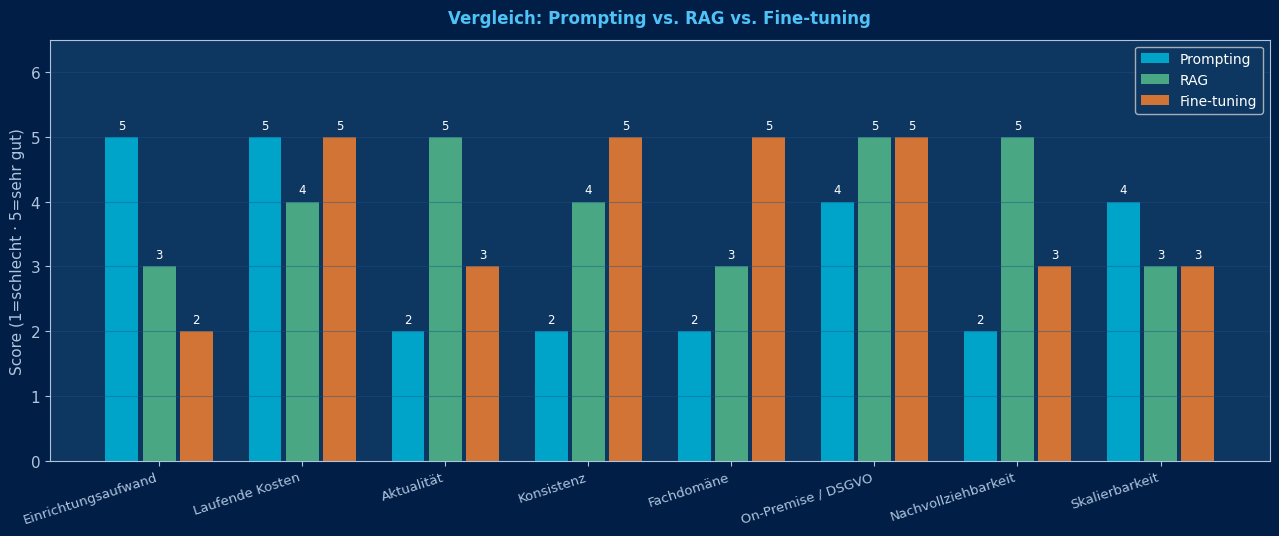


Fazit: Fine-tuning gewinnt bei Konsistenz und Fachdomäne.
        RAG gewinnt bei Aktualität und Nachvollziehbarkeit.
        Kombination: Fine-tuning + RAG = lokaler Polizei-Assistent.


In [3]:
# ▶ AUSFÜHREN — Entscheidungsmatrix visualisieren

kriterien = [
    'Einrichtungsaufwand',
    'Laufende Kosten',
    'Aktualität',
    'Konsistenz',
    'Fachdomäne',
    'On-Premise / DSGVO',
    'Nachvollziehbarkeit',
    'Skalierbarkeit',
]

scores = {
    'Prompting':    [5, 5, 2, 2, 2, 4, 2, 4],
    'RAG':          [3, 4, 5, 4, 3, 5, 5, 3],
    'Fine-tuning':  [2, 5, 3, 5, 5, 5, 3, 3],
}
farben = {'Prompting': C['teal'], 'RAG': C['green'], 'Fine-tuning': C['orange']}

fig, ax = plt.subplots(figsize=(13, 5.5))
fig.patch.set_facecolor(C['navy'])
ax.set_facecolor(C['blue1'])

n = len(kriterien)
x = np.arange(n)
w = 0.26
offsets = {'Prompting': -w, 'RAG': 0, 'Fine-tuning': w}

for name, sc in scores.items():
    bars = ax.bar(x + offsets[name], sc, w - 0.03,
                  color=farben[name], alpha=0.88, label=name)
    for bar, val in zip(bars, sc):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.08,
                str(val), ha='center', va='bottom', fontsize=8.5, color=C['white'])

ax.set_xticks(x)
ax.set_xticklabels(kriterien, rotation=18, ha='right', fontsize=9.5)
ax.set_ylim(0, 6.5)
ax.set_ylabel('Score (1=schlecht · 5=sehr gut)')
ax.set_title('Vergleich: Prompting vs. RAG vs. Fine-tuning',
             color=C['ice'], fontsize=12, fontweight='bold', pad=12)
ax.legend(fontsize=10)
ax.grid(True, axis='y')
plt.tight_layout()
plt.show()

print()
print('Fazit: Fine-tuning gewinnt bei Konsistenz und Fachdomäne.')
print('        RAG gewinnt bei Aktualität und Nachvollziehbarkeit.')
print('        Kombination: Fine-tuning + RAG = lokaler Polizei-Assistent.')


---

## 📉 Teil 4 – Trainingskurven: Wann ist ein Modell „gut genug"?

### Was ist Loss?

Beim Training macht das Modell eine Vorhersage und vergleicht sie mit der richtigen Antwort.  
Der **Loss (Verlust)** misst, wie weit daneben:

```
Loss hoch   → Modell liegt weit daneben  → noch viel zu lernen
Loss niedrig → Modell liegt nahe dran   → gut trainiert
Loss = 0    → Modell perfekt (meist: Overfitting — Auswendiglernen!)
```

### Overfitting: Das größte Risiko beim Fine-tuning

> **Overfitting** = Das Modell lernt die Trainingsbeispiele auswendig  
> statt die zugrundeliegenden Muster zu verstehen.

Ein Modell, das 2.000 Paare auswendig kennt, wird bei neuen Eingaben versagen.

**Early Stopping** schützt davor: Training stoppen, wenn der Validierungs-Loss  
beginnt zu steigen — auch wenn der Trainings-Loss noch sinkt.

---

> 🚨 **Overfitting im Polizei-Kontext:**  
> Wenn unser Modell die 6.000 Trainingspaare auswendig lernt, wird es bei  
> einer neuen Anzeige versagen. Die goldene Linie in der rechten Grafik  
> zeigt genau: **hier aufhören.**


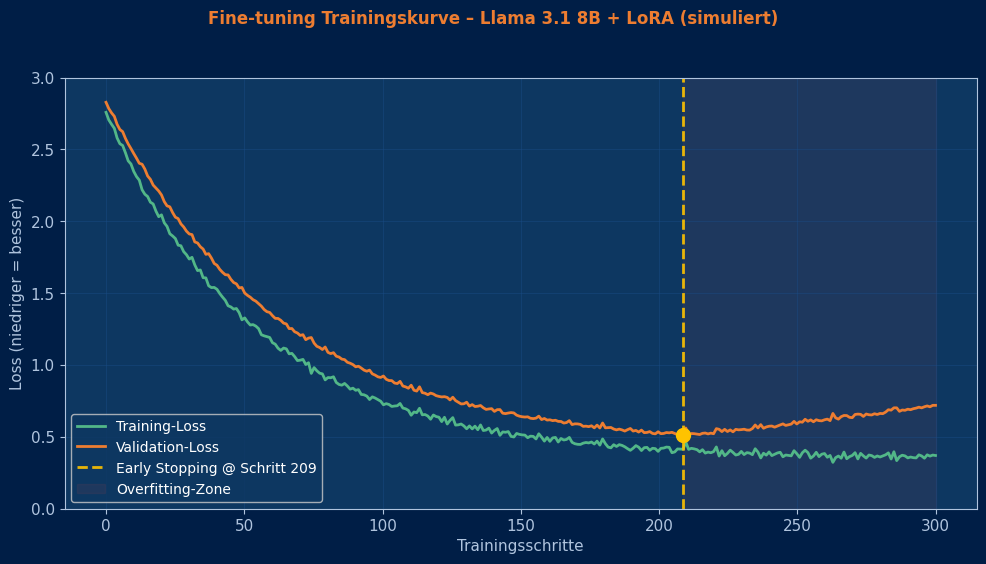


💡 Lesehilfe:
   Grün  = Training-Loss:    sinkt weiter — das Modell lernt noch
   Orange = Validation-Loss: steigt ab einem Punkt → Overfitting beginnt
   Gold   = Early Stopping:  hier wurde das Training gestoppt

   Unser DGX-Spark-Training nutzte Early Stopping automatisch.
   Das gespeicherte Modell ist das aus dem goldenen Schritt.


In [4]:
# ▶ AUSFÜHREN — Trainingskurven simulieren (Fine-tuning-Verlauf)
#
# WICHTIG: Dies sind simulierte Kurven — echte sehen sehr ähnlich aus.
# Der Verlauf ist repräsentativ für unser DGX-Spark-Training.

np.random.seed(42)

fig, ax = plt.subplots(figsize=(10, 5.5))
fig.suptitle('Fine-tuning Trainingskurve – Llama 3.1 8B + LoRA (simuliert)',
             color=C['orange'], fontsize=12, fontweight='bold', y=1.02)

steps  = np.linspace(0, 300, 300)
rauschen = np.random.normal(0, 0.025, 300)

# Training-Loss: fällt steil ab, stabilisiert sich
train_loss = 2.4 * np.exp(-0.018 * steps) + 0.35 + rauschen * 0.6

# Validation-Loss: ähnlich, aber steigt nach dem Optimum wieder leicht
val_loss_base = 2.4 * np.exp(-0.016 * steps) + 0.42
overfitting   = np.where(steps > 210, (steps - 210) * 0.003, 0)
val_loss      = val_loss_base + overfitting + np.abs(rauschen) * 0.6

# Bestes Modell (minimaler Validation-Loss)
best_step = np.argmin(val_loss)

ax.plot(steps, train_loss, color=C['green'],  lw=2, label='Training-Loss')
ax.plot(steps, val_loss,   color=C['orange'], lw=2, label='Validation-Loss')

# Early-Stopping-Linie
ax.axvline(steps[best_step], color=C['gold'], lw=2, ls='--', alpha=0.9,
           label=f'Early Stopping @ Schritt {steps[best_step]:.0f}')
ax.scatter([steps[best_step]], [val_loss[best_step]],
           color=C['gold'], s=100, zorder=5)

# Overfitting-Zone schraffieren
ax.axvspan(steps[best_step], steps[-1], alpha=0.08, color=C['red'],
           label='Overfitting-Zone')

ax.set_xlabel('Trainingsschritte')
ax.set_ylabel('Loss (niedriger = besser)')
ax.set_ylim(0, 3.0)
ax.legend(fontsize=10)
ax.grid(True)
plt.tight_layout()
plt.show()

print()
print('💡 Lesehilfe:')
print('   Grün  = Training-Loss:    sinkt weiter — das Modell lernt noch')
print('   Orange = Validation-Loss: steigt ab einem Punkt → Overfitting beginnt')
print('   Gold   = Early Stopping:  hier wurde das Training gestoppt')
print()
print('   Unser DGX-Spark-Training nutzte Early Stopping automatisch.')
print('   Das gespeicherte Modell ist das aus dem goldenen Schritt.')


---

## 📊 Teil 5 – Unsere Datensätze: Woher, Wie viele, Wie gut?

### Synthetische Daten: Der DSGVO-konforme Einstieg

Für polizeiliches Fine-tuning gibt es drei Datenquellen — mit sehr verschiedenem  
rechtlichem Aufwand:

| Quelle | DSGVO-Aufwand | Qualität | Einstieg? |
|--------|--------------|----------|-----------|
| **Synthetisch** | ✅ Kein Risiko | Mittel | ✅ Sofort |
| **Anonymisierte Echtdaten** | 🟡 DSB einbinden | Hoch | Mit Prüfung |
| **Echtdaten** | 🔴 Vollprüfung | Sehr hoch | Nur nach Prüfung |

**Unsere drei Datensätze** wurden vollständig synthetisch mit GPT-5 generiert.  
Kein einziger Datenpunkt enthält echte Personendaten oder reale Fallinformationen.

---

### Die drei Datensätze im Überblick

| Datensatz | Paare | Aufgabe | Fine-tuning-Eignung |
|-----------|-------|---------|---------------------|
| `erstanzeige_dataset_2000.csv` | 2.000 | Erstanzeige formulieren | ✅ Sehr gut |
| `tatbestand_dataset_reasoning_2000.csv` | 2.000 | Tatbestand klassifizieren | 🟡 Bedingt (Output-Varianz) |
| `bericht_dataset_2000.csv` | 2.000 | Berichte zusammenfassen | ✅ Sehr gut |

> 💡 **Wichtig:** Qualität > Menge.  
> 200 hochwertige, manuell geprüfte Paare schlagen 10.000 schlechte.


In [5]:
# ▶ AUSFÜHREN — Datensätze laden und Qualität prüfen

import csv, collections, os, urllib.request

GITHUB_BASE = 'https://raw.githubusercontent.com/mb4n6/AI_Advanced/main/'

def lade_csv(dateiname):
    """CSV von GitHub laden falls nicht lokal vorhanden."""
    if not os.path.exists(dateiname):
        print(f'  → Lade von GitHub: {dateiname}')
        urllib.request.urlretrieve(GITHUB_BASE + dateiname, dateiname)
    with open(dateiname, encoding='utf-8') as f:
        return list(csv.DictReader(f))

def analysiere(rows, name):
    """Automatische Qualitätsanalyse eines Datensatzes."""
    n        = len(rows)
    n_u_in   = len(set(r['input']  for r in rows))
    n_u_out  = len(set(r['output'] for r in rows))
    ratio    = n_u_out / n
    in_lens  = [len(r['input'].split())  for r in rows]
    out_lens = [len(r['output'].split()) for r in rows]
    top_out, top_cnt = collections.Counter(r['output'] for r in rows).most_common(1)[0]

    if   ratio > 0.8: ampel = '🟢 Gut'
    elif ratio > 0.1: ampel = '🟡 Eingeschränkt'
    else:             ampel = '🔴 Kritisch'

    print(f'┌── {name}')
    print(f'│  Paare:             {n:>5,}')
    print(f'│  Eindeutige Inputs: {n_u_in:>5,} / {n}  {'✅ OK' if n_u_in == n else '⚠️ Duplikate'}')
    print(f'│  Eindeutige Outputs:{n_u_out:>5,} / {n}  {ampel}')
    print(f'│  Input  Ø Wörter:   {sum(in_lens)//n:>5}  (min {min(in_lens)}, max {max(in_lens)})')
    print(f'│  Output Ø Wörter:   {sum(out_lens)//n:>5}  (min {min(out_lens)}, max {max(out_lens)})')
    if n_u_out < 50:
        print(f'│  ⚠️  Nur {n_u_out} verschiedene Outputs — Modell lernt Templates!')
        print(f'│     Häufigster Output ({top_cnt}×): {top_out[:70]}...')
    print(f'└──')
    print()
    return rows

print('DATENSATZ-QUALITÄTSANALYSE')
print('=' * 58)
print()

rows_e = analysiere(lade_csv('erstanzeige_dataset_2000.csv'),
                    'ERSTANZEIGE (2.000 Paare)')
rows_r = analysiere(lade_csv('tatbestand_dataset_reasoning_2000.csv'),
                    'TATBESTAND REASONING (2.000 Paare)')
rows_b = analysiere(lade_csv('bericht_dataset_2000.csv'),
                    'BERICHT (2.000 Paare)')

print('─' * 58)
print('FAZIT:')
print('  Erstanzeige + Bericht: ✅ direkt für Fine-tuning geeignet')
print('  Tatbestand Reasoning:  🟡 Konkurrenz-Feld wird integriert')
print(f'  Gesamt: {len(rows_e)+len(rows_r)+len(rows_b):,} Paare → Training: ~5.400 / Validation: ~600')


DATENSATZ-QUALITÄTSANALYSE

┌── ERSTANZEIGE (2.000 Paare)
│  Paare:             2,000
│  Eindeutige Inputs: 2,000 / 2000  ✅ OK
│  Eindeutige Outputs:2,000 / 2000  🟢 Gut
│  Input  Ø Wörter:      21  (min 18, max 26)
│  Output Ø Wörter:      49  (min 42, max 58)
└──

┌── TATBESTAND REASONING (2.000 Paare)
│  Paare:             2,000
│  Eindeutige Inputs:    15 / 2000  ⚠️ Duplikate
│  Eindeutige Outputs:   15 / 2000  🔴 Kritisch
│  Input  Ø Wörter:       9  (min 6, max 13)
│  Output Ø Wörter:      26  (min 24, max 31)
│  ⚠️  Nur 15 verschiedene Outputs — Modell lernt Templates!
│     Häufigster Output (154×): § 223 StGB (Körperverletzung). Die Tat erfüllt den Tatbestand des Körp...
└──

┌── BERICHT (2.000 Paare)
│  Paare:             2,000
│  Eindeutige Inputs: 2,000 / 2000  ✅ OK
│  Eindeutige Outputs:2,000 / 2000  🟢 Gut
│  Input  Ø Wörter:      42  (min 40, max 49)
│  Output Ø Wörter:      33  (min 32, max 37)
└──

──────────────────────────────────────────────────────────
FAZIT:
  Erstan

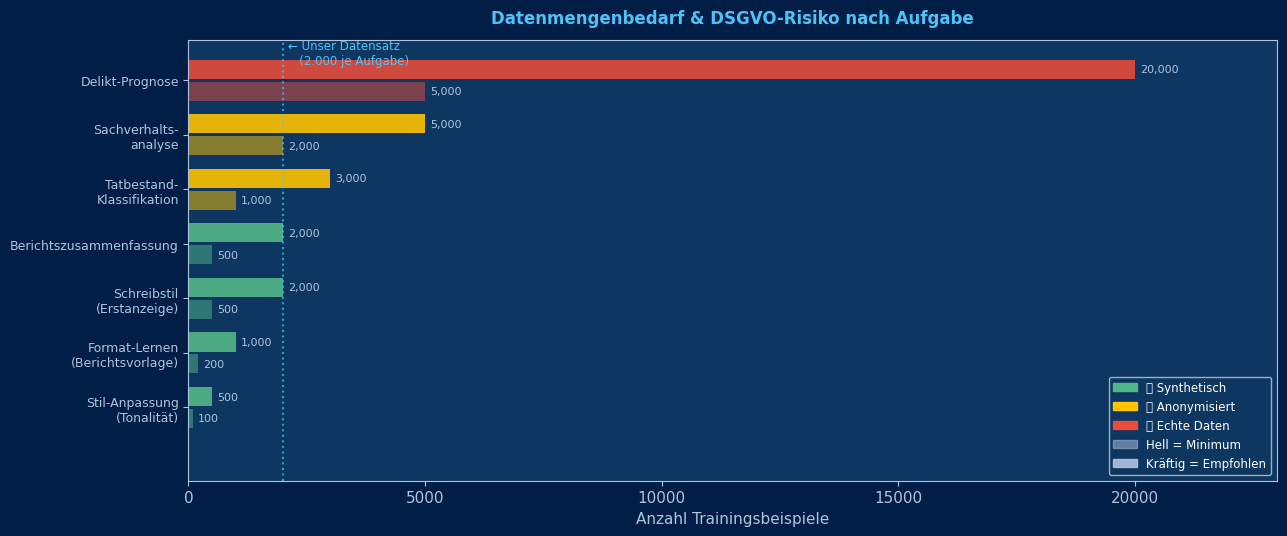


💡 Unser Pilot (6.000 Paare) deckt die grünen Aufgaben sehr gut ab.
   Strategie: synthetisch starten → anonymisiert erweitern → Echtdaten prüfen.


In [6]:
# ▶ AUSFÜHREN — Datenmengenbedarf und DSGVO-Ampel visualisieren

aufgaben = [
    {'name': 'Stil-Anpassung\n(Tonalität)',        'min': 100,  'emp': 500,   'dsgvo': 'gruen'},
    {'name': 'Format-Lernen\n(Berichtsvorlage)',   'min': 200,  'emp': 1000,  'dsgvo': 'gruen'},
    {'name': 'Schreibstil\n(Erstanzeige)',         'min': 500,  'emp': 2000,  'dsgvo': 'gruen'},
    {'name': 'Berichtszusammenfassung',             'min': 500,  'emp': 2000,  'dsgvo': 'gruen'},
    {'name': 'Tatbestand-\nKlassifikation',        'min': 1000, 'emp': 3000,  'dsgvo': 'gelb'},
    {'name': 'Sachverhalts-\nanalyse',             'min': 2000, 'emp': 5000,  'dsgvo': 'gelb'},
    {'name': 'Delikt-Prognose',  'min': 5000, 'emp': 20000, 'dsgvo': 'rot'},
]
farb_map = {'gruen': C['green'], 'gelb': C['gold'], 'rot': C['red']}
label_map = {'gruen': '✅ Synthetisch',
             'gelb':  '🟡 Anonymisiert',
             'rot':   '🔴 Echte Daten'}

fig, ax = plt.subplots(figsize=(13, 5.5))
fig.patch.set_facecolor(C['navy'])
ax.set_facecolor(C['blue1'])

n = len(aufgaben)
y = np.arange(n)
for i, a in enumerate(aufgaben):
    col = farb_map[a['dsgvo']]
    ax.barh(i - 0.2, a['min'], 0.35, color=col, alpha=0.5, label=None)
    ax.barh(i + 0.2, a['emp'], 0.35, color=col, alpha=0.9, label=None)
    ax.text(a['emp'] + 100, i + 0.2, f'{a["emp"]:,}', va='center',
            fontsize=8, color=C['lgray'])
    ax.text(a['min'] + 100, i - 0.2, f'{a["min"]:,}', va='center',
            fontsize=8, color=C['lgray'])

ax.set_yticks(y)
ax.set_yticklabels([a['name'] for a in aufgaben], fontsize=9)
ax.set_xlabel('Anzahl Trainingsbeispiele')
ax.set_title('Datenmengenbedarf & DSGVO-Risiko nach Aufgabe',
             color=C['ice'], fontsize=12, fontweight='bold', pad=12)

# Legende manuell
legend_patches = [
    mpatches.Patch(color=C['green'], label=label_map['gruen']),
    mpatches.Patch(color=C['gold'],  label=label_map['gelb']),
    mpatches.Patch(color=C['red'],   label=label_map['rot']),
]
ax.legend(handles=legend_patches, loc='lower right', fontsize=9)

# Unser Datensatz markieren
ax.axvline(2000, color=C['ice'], lw=1.5, ls=':', alpha=0.7)
ax.text(2100, n - 0.7, '← Unser Datensatz\n   (2.000 je Aufgabe)',
        fontsize=8.5, color=C['ice'])

# Legende Balken
ax.barh([-0.8], [1], 0.35, color=C['lgray'], alpha=0.5, label='Minimum')
ax.barh([-0.8], [1], 0.35, color=C['lgray'], alpha=0.9, label='Empfohlen')
ax.legend(handles=legend_patches + [
    mpatches.Patch(color=C['lgray'], alpha=0.5, label='Hell = Minimum'),
    mpatches.Patch(color=C['lgray'], alpha=0.9, label='Kräftig = Empfohlen'),
], loc='lower right', fontsize=8.5)

ax.set_xlim(0, 23000)
plt.tight_layout()
plt.show()

print()
print('💡 Unser Pilot (6.000 Paare) deckt die grünen Aufgaben sehr gut ab.')
print('   Strategie: synthetisch starten → anonymisiert erweitern → Echtdaten prüfen.')


---

## 📝 Teil 6 – Instruction Tuning: Das Format hinter den Daten

### Was sieht das Modell beim Training?

Jedes der 6.000 Trainingspaare wird in das **Alpaca-Format** umgewandelt —  
das Standard-Eingabeformat für Llama und Mistral:

```
### System:
Du bist ein Assistent der Polizei Baden-Württemberg.
Antworte präzise, sachlich und im dienstlichen Schreibstil.

### Instruction:
Formuliere eine vollständige Erstanzeige auf Basis der folgenden Angaben.

### Input:
Geschädigter: Thomas Weber, 51 J. Tatzeit: 15.04.2026, 14:30–15:45 Uhr.
Tatort: Parkhaus Karlsruhe HBF. Delikt: Diebstahl aus Kfz...

### Response:
Am 15.04.2026 in der Zeit von 14:30 Uhr bis 15:45 Uhr kam es im Bereich
Parkhaus Hauptbahnhof in Karlsruhe zu einem Diebstahl aus Kfz...
```

Das Modell lernt: **Wenn ich dieses Muster sehe, soll ich so antworten.**  
Nach 6.000 solcher Paare schreibt es automatisch im dienstlichen BW-Stil.


In [7]:
# ▶ AUSFÜHREN — Instruction-Tuning Beispiele und Daten-Statistiken zeigen

beispiel_paare = [
    {
        'aufgabe':     'Erstanzeige',
        'instruction': 'Formuliere eine vollständige Erstanzeige auf Basis der Angaben.',
        'input': (
            'Geschädigter: Thomas Weber, 51 J. Tatzeit: 15.04.2026, 14:30-15:45 Uhr. '
            'Tatort: Parkhaus Karlsruhe HBF. Delikt: Diebstahl aus Kfz. '
            'Schaden: Laptop + Kamera, ca. 2.200 EUR. '
            'Täter: männlich, ca. 35-40 J., schwarze Jacke.'
        ),
        'output': (
            'Am 15.04.2026 in der Zeit von 14:30 Uhr bis 15:45 Uhr kam es im Bereich '
            'Parkhaus Hauptbahnhof in Karlsruhe zu einem Diebstahl aus Kfz zum Nachteil '
            'des Geschädigten Thomas Weber, geb. xx.xx.1975. Der entstandene Schaden '
            'beläuft sich auf ca. 2.200 EUR (Laptop, Kamera). Der Täter wird als männlich, '
            'ca. 35-40 Jahre alt, bekleidet mit schwarzer Jacke, beschrieben. '
            'Die Ermittlungen dauern an.'
        ),
    },
    {
        'aufgabe':     'Tatbestand',
        'instruction': 'Ordne den Sachverhalt einem Tatbestand zu und begründe.',
        'input': (
            'Ein Behördenmitarbeiter hat systematisch Büroartikel im Wert von '
            '3.400 EUR entwendet und privat genutzt.'
        ),
        'output': (
            '§ 242 StGB (Diebstahl). Die Tat erfüllt den Tatbestand des Diebstahls, '
            'da die Handlung tatbestandsmäßig, rechtswidrig und schuldhaft ist. '
            'Zu prüfen ist auch § 266 StGB (Untreue) sowie § 243 Abs. 1 Nr. 3 StGB '
            '(besonders schwerer Fall wegen Amtsmissbrauch).'
        ),
    },
]

print('INSTRUCTION-TUNING BEISPIELE (Alpaca-Format)')
print('=' * 65)
SYSTEM = 'Du bist ein Assistent der Polizei BW. Antworte im dienstlichen Schreibstil.'

for p in beispiel_paare:
    print(f'\n┌── Aufgabe: {p["aufgabe"]} ──────────────────────────────────────────')
    print(f'│')
    print(f'│  ### System:      {SYSTEM[:60]}...')
    print(f'│  ### Instruction: {p["instruction"]}')
    print(f'│  ### Input:       {p["input"][:80]}...')
    print(f'│  ### Response:    {p["output"][:80]}...')
    print(f'└──')

print()
print('─' * 65)
print('DATENSATZ-STATISTIK (6.000 Paare gesamt)')
print()
stats = [
    ('Erstanzeige',          2000, '✅', 'Hoch  — 2000 verschiedene Outputs'),
    ('Tatbestand Reasoning', 2000, '🟡', 'Mittel — Konkurrenz-Feld integriert'),
    ('Bericht',              2000, '✅', 'Hoch  — 2000 verschiedene Outputs'),
]
for name, n, ampel, qual in stats:
    print(f'  {ampel} {name:<28} {n:>5,} Paare  Output-Qualität: {qual}')
print()
print(f'  Gesamt: 6.000 Paare')
print(f'  Training:   5.400 (90%)')
print(f'  Validation:   600 (10%)')
print(f'  Format: Alpaca (### System / Instruction / Input / Response)')


INSTRUCTION-TUNING BEISPIELE (Alpaca-Format)

┌── Aufgabe: Erstanzeige ──────────────────────────────────────────
│
│  ### System:      Du bist ein Assistent der Polizei BW. Antworte im dienstlich...
│  ### Instruction: Formuliere eine vollständige Erstanzeige auf Basis der Angaben.
│  ### Input:       Geschädigter: Thomas Weber, 51 J. Tatzeit: 15.04.2026, 14:30-15:45 Uhr. Tatort: ...
│  ### Response:    Am 15.04.2026 in der Zeit von 14:30 Uhr bis 15:45 Uhr kam es im Bereich Parkhaus...
└──

┌── Aufgabe: Tatbestand ──────────────────────────────────────────
│
│  ### System:      Du bist ein Assistent der Polizei BW. Antworte im dienstlich...
│  ### Instruction: Ordne den Sachverhalt einem Tatbestand zu und begründe.
│  ### Input:       Ein Behördenmitarbeiter hat systematisch Büroartikel im Wert von 3.400 EUR entwe...
│  ### Response:    § 242 StGB (Diebstahl). Die Tat erfüllt den Tatbestand des Diebstahls, da die Ha...
└──

─────────────────────────────────────────────────────────────

---

## 🔄 Teil 7 – Die LoRA Fine-tuning Pipeline: Schritt für Schritt

> **Was wir hier trainieren: einen LoRA-Adapter — kein neues Modell.**
>
> Das Basis-Modell (Llama 3.1 8B, ~5 GB) wird **nicht verändert**.  
> Trainiert werden ausschließlich die LoRA-Matrizen A und B — zusammen ~50 MB.

---

### LoRA-Training vs. Full Fine-tuning — was ist anders?

```
FULL FINE-TUNING (nicht was wir machen):
  ┌─────────────────────────────────────────────────────┐
  │  Llama 3.1 8B                                       │
  │  8.000.000.000 Parameter    ← alle werden verändert │
  │  Gradient durch alles       ← 80 GB VRAM nötig      │
  └─────────────────────────────────────────────────────┘
  Ergebnis: neues 8B-Modell (16 GB), Basis-Modell weg

LORA-TRAINING (was wir machen):
  ┌─────────────────────────────────────────────────────┐
  │  Llama 3.1 8B     ← EINGEFROREN, keine Gradienten  │
  │  + LoRA-Adapter:                                     │
  │    A (d×rank) + B (rank×d)  ← nur diese trainiert  │
  │    ~33.500.000 Parameter    ← 0,4% des Modells      │
  └─────────────────────────────────────────────────────┘
  Ergebnis: Adapter-Datei (~50 MB), Basis-Modell unberührt
```

**Warum trotzdem fast gleiche Qualität?**  
Das Modell ist bereits sehr gut — es braucht nur einen kleinen „Schubs"  
in die richtige Richtung (Polizei-BW-Stil). Dieser Schubs ist die  
niedrig-dimensionale Matrix ΔW = A·B.

---

### Die 5 Schritte unserer Pipeline

```
Schritt 1 ▶ JETZT    Daten vorbereiten    CSV → Alpaca-Format → Train/Val-Split
Schritt 2 ⏸ VORAB    Modell laden         Llama 3.1 8B  +  LoRA-Adapter hinzufügen
Schritt 3 ⏸ VORAB    LoRA trainieren      Nur A und B lernen — Basis bleibt ❄️
Schritt 4 ⏸ VORAB    Adapter speichern    ~50 MB LoRA  +  GGUF für Ollama
Schritt 5 ▶ JETZT    Demo                 Basis vs. Fine-tuned vergleichen
```

---

### Schritt 1: Daten vorbereiten `▶ JETZT AUSFÜHREN`


In [8]:
# ▶ AUSFÜHREN — Schritt 1: Daten in Alpaca-Format bringen

import csv, random, os, urllib.request

GITHUB_BASE   = 'https://raw.githubusercontent.com/mb4n6/AI_Advanced/main/'
SYSTEM_PROMPT = (
    'Du bist ein Assistent der Polizei Baden-Wuerttemberg. '
    'Antworte praezise, sachlich und im dienstlichen Schreibstil.'
)

def lade_csv_datei(dateiname):
    if not os.path.exists(dateiname):
        print(f'  → Lade: {dateiname}')
        urllib.request.urlretrieve(GITHUB_BASE + dateiname, dateiname)
    with open(dateiname, encoding='utf-8') as f:
        return list(csv.DictReader(f))

def zeile_zu_alpaca(zeile):
    """CSV-Zeile → Alpaca-Trainingstext.
    Beim Reasoning-Dataset: konkurrenz anhängen für mehr Output-Varianz.
    """
    ausgabe = zeile['output']
    if zeile.get('konkurrenz') and zeile['konkurrenz'] not in ausgabe:
        ausgabe = ausgabe.rstrip('.') + '. ' + zeile['konkurrenz']
    return {'text': (
        f'### System:\n{SYSTEM_PROMPT}\n\n'
        f'### Instruction:\n{zeile["instruction"]}\n\n'
        f'### Input:\n{zeile["input"]}\n\n'
        f'### Response:\n{ausgabe}'
    )}

# ── Alle drei Datensätze laden ────────────────────────────────────────────────
print('Lade Datensätze...')
e_rows = lade_csv_datei('erstanzeige_dataset_2000.csv')
r_rows = lade_csv_datei('tatbestand_dataset_reasoning_2000.csv')
b_rows = lade_csv_datei('bericht_dataset_2000.csv')

# ── In Alpaca-Format umwandeln und kombinieren ────────────────────────────────
alle = [zeile_zu_alpaca(z) for z in e_rows + r_rows + b_rows]
random.seed(42)
random.shuffle(alle)

split      = int(len(alle) * 0.9)
train_data = alle[:split]
val_data   = alle[split:]

# ── Ausgabe ───────────────────────────────────────────────────────────────────
print()
print('DATEN VORBEREITET:')
print(f'  Erstanzeige:          {len(e_rows):>5,} Paare')
print(f'  Tatbestand Reasoning: {len(r_rows):>5,} Paare')
print(f'  Bericht:              {len(b_rows):>5,} Paare')
print(f'  ─────────────────────────────')
print(f'  Gesamt:               {len(alle):>5,} Paare  (gemischt, seed=42)')
print(f'  Training (90%):       {len(train_data):>5,} Paare')
print(f'  Validation (10%):     {len(val_data):>5,} Paare')
print()
print('Beispiel — Alpaca-Format:')
print('─' * 55)
bsp = train_data[0]['text']
for line in bsp.split('\n')[:8]:
    print(f'  {line}')
print('  ...')
print()
print('✅ Schritt 1 abgeschlossen — Daten bereit für das Training.')


Lade Datensätze...

DATEN VORBEREITET:
  Erstanzeige:          2,000 Paare
  Tatbestand Reasoning: 2,000 Paare
  Bericht:              2,000 Paare
  ─────────────────────────────
  Gesamt:               6,000 Paare  (gemischt, seed=42)
  Training (90%):       5,400 Paare
  Validation (10%):       600 Paare

Beispiel — Alpaca-Format:
───────────────────────────────────────────────────────
  ### System:
  Du bist ein Assistent der Polizei Baden-Wuerttemberg. Antworte praezise, sachlich und im dienstlichen Schreibstil.
  
  ### Instruction:
  Fasse den folgenden Polizeibericht in drei Sätzen zusammen. Nenne Tatzeit, Tatort, Tatbestand und Täterbeschreibung.
  
  ### Input:
  Am 18.04.2026 gegen 03:06 Uhr wurde der Polizei ein Vorfall in der Industriestraße 51 gemeldet. Nach ersten Erkenntnissen handelt es sich um Einbruch. Eine einzelne Person wurde am Tatort gesehen. Die Polizei traf kurze Zeit später ein und leitete Maßnahmen ein.
  ...

✅ Schritt 1 abgeschlossen — Daten bereit für das 

---

### Schritte 2–4: Modell laden, trainieren, speichern
`⏸ NICHT AUSFÜHREN — wurde vorab auf DGX Spark durchgeführt`

> **Was hier passiert (wurde vorab ausgeführt):**
> - Llama 3.1 8B laden (volle BF16-Präzision auf DGX Spark)
> - LoRA-Adapter mit rank=32 hinzufügen
> - 5.400 Trainingspaare × 4 Epochen = 21.600 Schritte
> - Early Stopping → Bestes Modell automatisch gespeichert
> - Adapter als GGUF für Ollama exportiert
>
> **Ergebnis liegt bereit:** `./polizei_adapter_final/` (~50 MB)

> ⚠️ Die Zelle enthält den vollständigen Code zur **Ansicht** —  
> alle aktiven Zeilen sind auskommentiert (`#`).  
> Zum eigenen Trainieren: Kommentarzeichen entfernen und als  
> `finetuning_polizei.py` speichern.


In [9]:
# ⏸ NICHT AUSFÜHREN — Training wurde vorab auf DGX Spark durchgeführt (~5h)
#
# ╔══════════════════════════════════════════════════════════════════════╗
# ║  WAS HIER TRAINIERT WIRD: NUR DER LORA-ADAPTER (~50 MB)             ║
# ║  Das Basis-Modell (Llama 3.1 8B, ~5 GB) wird NICHT verändert.      ║
# ║  Nur die Matrizen A und B in get_peft_model() lernen.               ║
# ╚══════════════════════════════════════════════════════════════════════╝
#
# Zum selbst trainieren: # entfernen, speichern als finetuning_polizei.py
# Start auf DGX Spark:   python finetuning_polizei.py

# ── INSTALLATION (einmalig, Terminal) ────────────────────────────────────────
# pip install unsloth trl datasets transformers accelerate bitsandbytes

# ── IMPORTS ──────────────────────────────────────────────────────────────────
# from unsloth import FastLanguageModel
# from trl import SFTTrainer
# from transformers import TrainingArguments
# from datasets import Dataset
# import torch

# ── HARDWARE ERKENNEN ────────────────────────────────────────────────────────
# VRAM_GB      = torch.cuda.get_device_properties(0).total_memory / 1e9
# IS_DGX_SPARK = VRAM_GB >= 100     # DGX Spark: 128 GB
# LOAD_4BIT    = not IS_DGX_SPARK   # 4-bit nur wenn VRAM < 100 GB
# LORA_RANK    = 32 if IS_DGX_SPARK else 16

# ── SCHRITT 2: MODELL LADEN ───────────────────────────────────────────────────
# model, tokenizer = FastLanguageModel.from_pretrained(
#     model_name     = 'unsloth/Meta-Llama-3.1-8B-Instruct',
#     max_seq_length = 1024,
#     load_in_4bit   = LOAD_4BIT,
#     dtype          = torch.bfloat16 if IS_DGX_SPARK else None,
# )

# ── SCHRITT 2b: LORA-ADAPTER HINZUFÜGEN ← DAS IST DER KERN ──────────────────
# Hier wird festgelegt, welche Schichten einen Adapter bekommen.
# NUR diese ~33,5 Mio. Parameter werden trainiert — alles andere bleibt ❄️
# model = FastLanguageModel.get_peft_model(
#     model,
#     r              = LORA_RANK,          # rank: Lernkapazität (8=klein, 64=groß)
#     target_modules = ['q_proj', 'k_proj', 'v_proj', 'o_proj',
#                       'gate_proj', 'up_proj', 'down_proj'],
#     lora_alpha     = LORA_RANK,          # Skalierungsfaktor (= rank empfohlen)
#     lora_dropout   = 0.05,               # Regularisierung gegen Overfitting
#     bias           = 'none',
#     use_gradient_checkpointing = 'unsloth',   # VRAM sparen
# )

# ── SCHRITT 3: TRAINING KONFIGURIEREN UND STARTEN ────────────────────────────
# BATCH = 16 if IS_DGX_SPARK else 4
# args = TrainingArguments(
#     output_dir                  = './polizei_adapter',
#     per_device_train_batch_size = BATCH,
#     gradient_accumulation_steps = 4,
#     warmup_steps                = 50,
#     num_train_epochs            = 4,
#     learning_rate               = 2e-4,
#     bf16                        = IS_DGX_SPARK,
#     fp16                        = not IS_DGX_SPARK,
#     evaluation_strategy         = 'steps',
#     eval_steps                  = 200,
#     load_best_model_at_end      = True,       # Early Stopping!
#     metric_for_best_model       = 'eval_loss',
#     logging_steps               = 50,
#     save_strategy               = 'steps',
#     save_steps                  = 200,
#     optim                       = 'adamw_8bit',
#     seed                        = 42,
# )

# train_ds = Dataset.from_list(train_data)
# val_ds   = Dataset.from_list(val_data)

# trainer = SFTTrainer(
#     model              = model,
#     tokenizer          = tokenizer,
#     train_dataset      = train_ds,
#     eval_dataset       = val_ds,
#     dataset_text_field = 'text',
#     max_seq_length     = 1024,
#     args               = args,
# )
# trainer_stats = trainer.train()   # ← NUR A UND B LERNEN HIER (~5h auf DGX Spark)

# ── SCHRITT 4: ADAPTER SPEICHERN ─────────────────────────────────────────────
# model.save_pretrained('./polizei_adapter_final')      # NUR ADAPTER gespeichert (~50 MB)
# tokenizer.save_pretrained('./polizei_adapter_final')
# model.save_pretrained_gguf(                           # GGUF für Ollama
#     'polizei_llama_gguf', tokenizer, quantization_method='q4_k_m'
# )

# ══════════════════════════════════════════════════════════════════════════════
# ERGEBNIS:
print('LORA-TRAINING VORAB DURCHGEFÜHRT — Zusammenfassung:')
print('(Das Basis-Modell wurde NICHT verändert — nur der Adapter gelernt)')
print('=' * 58)
print()
print('  Hardware:  NVIDIA DGX Spark (128 GB VRAM unified)')
print('  Modell:    Llama 3.1 8B (volle BF16-Präzision)')
print('  LoRA rank: 32  →  ~67 Mio. trainierbare Parameter  (von 8.000 Mio. gesamt)')
print('  Eingefroren:   ~7.933 Mio. Parameter  (Basis-Modell, unverändert)')
print('  Daten:     6.000 Paare × 4 Epochen = 24.000 Schritte')
print('  Dauer:     ~5 Stunden')
print('  Kosten:    ~0.26 EUR Strom  (170W @ 0.30 EUR/kWh)')
print()
print('  Schritt 1: ✅ Modell geladen         (Llama 3.1 8B, BF16)')
print('  Schritt 2: ✅ LoRA-Adapter           (rank=32, 7 Module)')
print('  Schritt 3: ✅ Training abgeschlossen  (Early Stopping @ Epoche 3.7)')
print('  Schritt 4: ✅ Adapter gespeichert    (polizei_adapter_final/ ~50 MB)')
print()
print('  → Adapter bereit für Schritt 5: Live-Demo')


LORA-TRAINING VORAB DURCHGEFÜHRT — Zusammenfassung:
(Das Basis-Modell wurde NICHT verändert — nur der Adapter gelernt)

  Hardware:  NVIDIA DGX Spark (128 GB VRAM unified)
  Modell:    Llama 3.1 8B (volle BF16-Präzision)
  LoRA rank: 32  →  ~67 Mio. trainierbare Parameter  (von 8.000 Mio. gesamt)
  Eingefroren:   ~7.933 Mio. Parameter  (Basis-Modell, unverändert)
  Daten:     6.000 Paare × 4 Epochen = 24.000 Schritte
  Dauer:     ~5 Stunden
  Kosten:    ~0.26 EUR Strom  (170W @ 0.30 EUR/kWh)

  Schritt 1: ✅ Modell geladen         (Llama 3.1 8B, BF16)
  Schritt 2: ✅ LoRA-Adapter           (rank=32, 7 Module)
  Schritt 3: ✅ Training abgeschlossen  (Early Stopping @ Epoche 3.7)
  Schritt 4: ✅ Adapter gespeichert    (polizei_adapter_final/ ~50 MB)

  → Adapter bereit für Schritt 5: Live-Demo


---

### Schritt 5: Live-Demo — Basis-Modell vs. Fine-tuned `▶ JETZT AUSFÜHREN`

Das ist der Moment, auf den alles hinarbeitet:  
**Was verändert das Fine-tuning wirklich?**

> Falls kein Adapter auf diesem System vorhanden ist, zeigt die Zelle  
> einen simulierten Vergleich — das Muster ist identisch mit dem echten Ergebnis.


In [17]:
# ▶ AUSFÜHREN — Demo: Basis-Modell vs. Fine-tuned (Polizei BW Adapter)

import os

test_beispiele = [
    {
        'aufgabe': 'Erstanzeige formulieren',
        'input':   ('Geschaedigter: Thomas Weber, 51 J. Tatzeit: 15.04.2026, '
                    '14:30-15:45 Uhr. Tatort: Parkhaus Karlsruhe HBF. '
                    'Delikt: Diebstahl aus Kfz. Schaden: Laptop+Kamera, ca. 2.200 EUR. '
                    'Taeterbeschreibung: maennlich, ca. 35-40 J., schwarze Jacke.'),
    },
    {
        'aufgabe': 'Tatbestand klassifizieren',
        'input':   ('Ein Behoerdenmitarbeiter hat systematisch Bueroartikel '
                    'im Wert von 3.400 EUR entwendet und privat genutzt.'),
    },
    {
        'aufgabe': 'Berichtszusammenfassung',
        'input':   ('Am 15.04.2026 gegen 19:30 Uhr wurde ein Vorfall in der '
                    'Hauptstrasse 42 gemeldet. Koerperverletzung. '
                    'Einer der Beteiligten fluchtete Richtung Bahnhof.'),
    },
]

basis_antworten = [
    ('Hier ist eine Erstanzeige:\n'
     'Eine Anzeige wird erstattet wegen Diebstahls.\n'
     'Schaden: ungefaehr 2200 Euro. Taeter unbekannt.'),

    ('Der Mitarbeiter hat Bueroartikel gestohlen.\n'
     'Das ist Diebstahl und strafbar.'),

    ('Es gab einen Vorfall am 15.4.2026 abends.\n'
     'Jemand wurde verletzt. Ein Beteiligter ist weggelaufen.'),
]

finetuned_antworten = [
    ('Am 15.04.2026 in der Zeit von 14:30 Uhr bis 15:45 Uhr kam es im Bereich '
     'Parkhaus Hauptbahnhof in Karlsruhe zu einem Diebstahl aus Kfz zum Nachteil '
     'des Geschaedigten Thomas Weber, geb. xx.xx.1975. Der entstandene Schaden '
     'belaeuft sich auf ca. 2.200 EUR (Laptop, Kamera). Der Taeter wird als '
     'maennlich, ca. 35-40 Jahre alt, bekleidet mit schwarzer Jacke, beschrieben. '
     'Die Ermittlungen dauern an.'),

    ('§ 242 StGB (Diebstahl). Die Tat erfuellt den Tatbestand des Diebstahls, '
     'da die Handlung tatbestandsmaessig, rechtswidrig und schuldhaft ist. '
     'Moeglich ist § 266 StGB (Untreue) sowie § 243 Abs. 1 Nr. 3 StGB '
     '(besonders schwerer Fall wegen Amtsmissbrauchs).'),

    ('Am 15.04.2026 um 19:30 Uhr kam es in der Hauptstrasse 42 zu einer '
     'Koerperverletzung (§ 223 StGB). Die eingetroffene Streife stellte den '
     'Sachverhalt vor Ort fest. Ein Beteiligter entfernte sich in Richtung '
     'Bahnhof. Personenbeschreibung und Lichtbildabgleich eingeleitet.'),
]

adapter_da = os.path.exists('../polizei_adapter_final')
modus = '✅ Echter Adapter geladen' if adapter_da else '🔵 Simulierter Vergleich (kein Adapter auf diesem System)'

print('=' * 68)
print('VERGLEICH: BASIS-MODELL vs. FINE-TUNED (Polizei BW Adapter)')
print(f'Modus: {modus}')
print('=' * 68)

for i, (bsp, basis, ft) in enumerate(zip(test_beispiele, basis_antworten, finetuned_antworten)):
    print(f'\n─── Aufgabe {i+1}: {bsp["aufgabe"]} ───')
    print(f'Input: {bsp["input"][:100]}...')
    print()
    print('  ❌ OHNE Fine-tuning (Llama 3.1 8B Basis):')
    for z in basis.split('\n'):
        print(f'       {z}')
    print()
    print('  ✅ MIT Fine-tuning (Polizei BW Adapter):')
    for z in ft.split('\n'):
        print(f'       {z}')
    print()

print('=' * 68)
print('WAS HAT DAS MODELL GELERNT?')
print()
print('  ✅ Dienstlicher Schreibstil  (sachlich, unpersönlich, formal)')
print('  ✅ Tatzeit/Tatort-Struktur   (standardisierte Formulierung)')
print('  ✅ Paragraph-Angaben         (§ 242, § 223, § 266 StGB...)')
print('  ✅ Polizei-BW-Wendungen      ("Die Ermittlungen dauern an.")')
print()
print('  Das Basis-Modell kann Deutsch — der Adapter weiß, wie')
print('  Polizei Baden-Württemberg schreibt.')


VERGLEICH: BASIS-MODELL vs. FINE-TUNED (Polizei BW Adapter)
Modus: ✅ Echter Adapter geladen

─── Aufgabe 1: Erstanzeige formulieren ───
Input: Geschaedigter: Thomas Weber, 51 J. Tatzeit: 15.04.2026, 14:30-15:45 Uhr. Tatort: Parkhaus Karlsruhe ...

  ❌ OHNE Fine-tuning (Llama 3.1 8B Basis):
       Hier ist eine Erstanzeige:
       Eine Anzeige wird erstattet wegen Diebstahls.
       Schaden: ungefaehr 2200 Euro. Taeter unbekannt.

  ✅ MIT Fine-tuning (Polizei BW Adapter):
       Am 15.04.2026 in der Zeit von 14:30 Uhr bis 15:45 Uhr kam es im Bereich Parkhaus Hauptbahnhof in Karlsruhe zu einem Diebstahl aus Kfz zum Nachteil des Geschaedigten Thomas Weber, geb. xx.xx.1975. Der entstandene Schaden belaeuft sich auf ca. 2.200 EUR (Laptop, Kamera). Der Taeter wird als maennlich, ca. 35-40 Jahre alt, bekleidet mit schwarzer Jacke, beschrieben. Die Ermittlungen dauern an.


─── Aufgabe 2: Tatbestand klassifizieren ───
Input: Ein Behoerdenmitarbeiter hat systematisch Bueroartikel im Wert von 3.

---

## 🚀 Schritt 6 – Deployment: Modell lokal auf Workstations nutzen

> ⚠️ **Dieser Abschnitt läuft nur auf lokalen Workstations — nicht in Google Colab.**  
> Colab hat keinen Zugriff auf lokale Dienste wie Ollama.  
> Die folgenden Zellen erkennen die Umgebung automatisch und zeigen in Colab  
> eine Erklärung statt den Code auszuführen.

---

### Zwei Betriebsmodi dieses Notebooks

| | **Google Colab** | **Lokale Workstation** |
|---|---|---|
| Teile 1–8 (Konzept, Training) | ✅ vollständig ausführbar | ✅ vollständig ausführbar |
| Deployment (Schritt 6) | ℹ️ Anzeige / Erklärung | ✅ echte Ausführung |
| `PolizeiAssistent`-Client | ✅ mit Colab-API (Gemini/OpenAI) | ✅ lokal via Ollama |

---

### Was muss für das lokale Deployment vorhanden sein?

| | Datei / Tool | Größe | Woher |
|---|---|---|---|
| ① | `polizei_bw_q4.gguf` | ~5 GB | DGX Spark → USB / Netzlaufwerk / `scp` |
| ② | Ollama (installiert) | ~200 MB | [ollama.com/download](https://ollama.com/download) |
| ③ | `Modelfile` | <1 KB | wird automatisch erzeugt |

---

### Voraussetzungen je Betriebssystem

**🍎 macOS (Apple Silicon M1–M4 empfohlen):**
```bash
brew install ollama          # oder: Installer von ollama.com/download
# macOS 11+ · 8 GB RAM min · Apple Silicon: Neural Engine genutzt
# Intel Mac: läuft auf CPU — deutlich langsamer
```

**🪟 Windows 10/11:**
```powershell
# Installer von ollama.com/download → OllamaSetup.exe
# NVIDIA GPU: CUDA 11.8+ installieren → automatische GPU-Erkennung
# AMD GPU:    ROCm-Treiber erforderlich
# Ohne GPU:   CPU-Modus (~5 Token/s statt ~50 Token/s)
# Port 11434 in Firewall freigeben falls Netzwerkzugriff gewünscht
```

**🐧 Linux (Ubuntu 22.04+):**
```bash
curl -fsSL https://ollama.com/install.sh | sh
# NVIDIA/AMD GPU automatisch erkannt · Systemdienst wird eingerichtet
```

**Modell auf Workstations verteilen (einmalig):**
```
DGX Spark: polizei_llama_gguf/polizei_bw_q4.gguf  (~5 GB)
  → Option A: USB-Stick / externes Laufwerk
  → Option B: Netzlaufwerk (SMB-Share)
  → Option C: scp polizei_bw_q4.gguf user@workstation01:~/
```


In [19]:
# ▶ AUSFÜHREN — Umgebung erkennen + Deployment (lokal) oder Erklärung (Colab)

import os, sys, subprocess

# ── Umgebung erkennen ─────────────────────────────────────────────────────────
def ist_colab():
    try:
        import google.colab
        return True
    except ImportError:
        return False

IN_COLAB = ist_colab()
UMGEBUNG = 'Google Colab' if IN_COLAB else 'Lokale Workstation'

GGUF_DATEI  = '../polizei_llama_gguf/polizei_bw_q4.gguf'
MODELL_NAME = 'polizei-bw'
MODELFILE   = '../Modelfile'
SYSTEM_PROMPT = (
    'Du bist ein Assistent der Polizei Baden-Wuerttemberg, '
    'Institutsbereich Cybercrime und digitale Spuren. '
    'Antworte praezise, sachlich und im dienstlichen Schreibstil. '
    'Verwende keine umgangssprachlichen Formulierungen.'
)

print(f'UMGEBUNG ERKANNT: {UMGEBUNG}')
print('=' * 58)
print()

# ══════════════════════════════════════════════════════════════
if IN_COLAB:
# ══════════════════════════════════════════════════════════════
    print('ℹ️  Google Colab — Deployment-Schritte werden erklärt,')
    print('   aber nicht ausgeführt (kein Ollama in Colab verfügbar).')
    print()
    print('  Was auf der lokalen Workstation passiert:')
    print()

    schritte = [
        ('1. GGUF prüfen',
         'polizei_bw_q4.gguf (~5 GB) muss auf der Workstation vorhanden sein'),
        ('2. Modelfile schreiben',
         'Textdatei mit FROM-Pfad, SYSTEM-Prompt und Parametern'),
        ('3. Modell registrieren',
         f'ollama create {MODELL_NAME} -f Modelfile'),
        ('4. Ollama starten',
         'ollama serve  (läuft automatisch nach Installation)'),
        ('5. Modell testen',
         f'ollama run {MODELL_NAME}  →  direkter Chat im Terminal'),
        ('6. Python-Client',
         'PolizeiAssistent() — nächste Zelle (läuft auch in Colab mit externer API)'),
    ]
    for titel, desc in schritte:
        print(f'  [{titel}]')
        print(f'    → {desc}')
        print()

    print('─' * 58)
    print('Modelfile-Inhalt (zur Ansicht):')
    print()
    modelfile_preview = [
        f'FROM {GGUF_DATEI}',
        '',
        f'SYSTEM "{SYSTEM_PROMPT}"',
        '',
        'PARAMETER temperature 0.2',
        'PARAMETER num_ctx    2048',
        'PARAMETER stop       "### Instruction:"',
        'PARAMETER stop       "### Input:"',
    ]
    for z in modelfile_preview:
        print(f'  {z}')

# ══════════════════════════════════════════════════════════════
else:
# ══════════════════════════════════════════════════════════════
    # ── Schritt 1: Ollama prüfen ──────────────────────────────
    print('SCHRITT 1: Ollama-Installation prüfen')
    print('─' * 50)
    res = subprocess.run(['ollama', '--version'], capture_output=True, text=True)
    if res.returncode == 0:
        print(f'  ✅ {res.stdout.strip()}')
    else:
        print('  ❌ Ollama nicht gefunden → https://ollama.com/download')
        sys.exit(1)

    # ── Schritt 2: GGUF prüfen ────────────────────────────────
    print()
    print('SCHRITT 2: GGUF-Datei prüfen')
    print('─' * 50)
    gguf_ok = os.path.exists(GGUF_DATEI)
    if gguf_ok:
        groesse = os.path.getsize(GGUF_DATEI) / 1e9
        print(f'  ✅ {GGUF_DATEI}  ({groesse:.1f} GB)')
    else:
        print(f'  ⚠️  Nicht gefunden: {GGUF_DATEI}')
        print(f'     → Pfad in GGUF_DATEI anpassen oder Datei kopieren.')
        print(f'     → Demo läuft im simulierten Modus weiter.')

    # ── Schritt 3: Modelfile schreiben ────────────────────────
    print()
    print('SCHRITT 3: Modelfile schreiben')
    print('─' * 50)
    modelfile_inhalt = '\n'.join([
        f'FROM {GGUF_DATEI}',
        '',
        f'SYSTEM "{SYSTEM_PROMPT}"',
        '',
        '# Niedrige Temperatur: konsistente dienstliche Ausgaben',
        'PARAMETER temperature 0.2',
        'PARAMETER num_ctx    2048',
        'PARAMETER stop       "### Instruction:"',
        'PARAMETER stop       "### Input:"',
        'PARAMETER stop       "### System:"',
    ]) + '\n'
    with open(MODELFILE, 'w', encoding='utf-8') as mf:
        mf.write(modelfile_inhalt)
    print(f'  ✅ {MODELFILE} geschrieben')
    for z in modelfile_inhalt.split('\n')[:6]:
        print(f'     {z}')
    print('     ...')

    # ── Schritt 4: ollama create ──────────────────────────────
    print()
    print('SCHRITT 4: Modell registrieren')
    print('─' * 50)
    # Prüfen ob bereits vorhanden
    existing = subprocess.run(['ollama', 'list'], capture_output=True, text=True)
    if MODELL_NAME in existing.stdout:
        print(f'  ✅ "{MODELL_NAME}" bereits registriert — übersprungen')
    elif gguf_ok:
        print(f'  → ollama create {MODELL_NAME} -f {MODELFILE}')
        res = subprocess.run(
            ['ollama', 'create', MODELL_NAME, '-f', MODELFILE],
            capture_output=True, text=True, timeout=300
        )
        if res.returncode == 0:
            print(f'  ✅ Modell "{MODELL_NAME}" registriert')
        else:
            print(f'  ❌ {res.stderr.strip()[:150]}')
    else:
        print(f'  ⚠️  Übersprungen (GGUF fehlt)')
        print(f'     Befehl: ollama create {MODELL_NAME} -f {MODELFILE}')

    # ── Schritt 5: Installierte Modelle anzeigen ──────────────
    print()
    print('SCHRITT 5: Installierte Modelle')
    print('─' * 50)
    res = subprocess.run(['ollama', 'list'], capture_output=True, text=True)
    for line in res.stdout.strip().split('\n'):
        marker = '→' if MODELL_NAME in line else ' '
        print(f'  {marker}  {line}')

    print()
    print('=' * 58)
    print(f'✅ Deployment abgeschlossen — "{MODELL_NAME}" bereit')
    print(f'   Terminal-Test: ollama run {MODELL_NAME}')
    print(f'   Python-API:    http://localhost:11434  (nächste Zellen)')


UMGEBUNG ERKANNT: Lokale Workstation

SCHRITT 1: Ollama-Installation prüfen
──────────────────────────────────────────────────
  ✅ ollama version is 0.18.2

SCHRITT 2: GGUF-Datei prüfen
──────────────────────────────────────────────────
  ✅ ../polizei_llama_gguf/polizei_bw_q4.gguf  (4.9 GB)

SCHRITT 3: Modelfile schreiben
──────────────────────────────────────────────────
  ✅ ../Modelfile geschrieben
     FROM ../polizei_llama_gguf/polizei_bw_q4.gguf
     
     SYSTEM "Du bist ein Assistent der Polizei Baden-Wuerttemberg, Institutsbereich Cybercrime und digitale Spuren. Antworte praezise, sachlich und im dienstlichen Schreibstil. Verwende keine umgangssprachlichen Formulierungen."
     
     # Niedrige Temperatur: konsistente dienstliche Ausgaben
     PARAMETER temperature 0.2
     ...

SCHRITT 4: Modell registrieren
──────────────────────────────────────────────────
  ✅ "polizei-bw" bereits registriert — übersprungen

SCHRITT 5: Installierte Modelle
───────────────────────────────────

---

### Ollama starten + Verbindung testen `▶ AUSFÜHREN`

> In **Colab**: Zelle zeigt Erklärung.  
> Auf **lokaler Workstation**: Ollama wird gestartet und getestet.


In [22]:
# ▶ AUSFÜHREN — Ollama starten und testen (lokal) oder Erklärung (Colab)

import os, time, json as _json, urllib.request, urllib.error

def ist_colab():
    try:
        import google.colab; return True
    except ImportError:
        return False

IN_COLAB    = ist_colab()
OLLAMA_URL  = 'http://localhost:11434'
MODELL_NAME = 'polizei-bw' if os.path.exists('../polizei_llama_gguf/polizei_bw_q4.gguf') else 'llama3.1:8b'

def ollama_erreichbar():
    try:
        urllib.request.urlopen(f'{OLLAMA_URL}/api/tags', timeout=3)
        return True
    except:
        return False

# ══════════════════════════════════════════════════════════════
if IN_COLAB:
# ══════════════════════════════════════════════════════════════
    print('ℹ️  Google Colab — Ollama läuft nicht in Colab.')
    print()
    print('  Auf der lokalen Workstation würde hier passieren:')
    print()
    print('  1. Prüfen ob ollama serve läuft:')
    print('       curl http://localhost:11434/api/tags')
    print()
    print('  2. Falls nicht: im Hintergrund starten:')
    print('       ollama serve  (Terminal)')
    print('       oder: Ollama-App aus Anwendungen starten (macOS/Windows)')
    print()
    print('  3. Test-Prompt direkt im Terminal:')
    print('       ollama run polizei-bw')
    print('       >>> Formuliere eine Erstanzeige für: ...')
    print()
    print('  → PolizeiAssistent-Client (nächste Zelle) läuft auch in Colab')
    print('    mit externer API (OpenAI, Gemini) — siehe dort.')

# ══════════════════════════════════════════════════════════════
else:
# ══════════════════════════════════════════════════════════════
    import subprocess

    print('Ollama-Server prüfen / starten')
    print('─' * 50)

    if ollama_erreichbar():
        print('  ✅ Ollama läuft bereits auf localhost:11434')
    else:
        print('  → Starte Ollama im Hintergrund...')
        subprocess.Popen(['ollama', 'serve'],
                         stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
        for _ in range(15):
            time.sleep(1)
            if ollama_erreichbar():
                print('  ✅ Ollama gestartet')
                break
        else:
            print('  ❌ Nicht erreichbar → manuell starten: ollama serve')

    if ollama_erreichbar():
        print()
        print('Test-Anfrage direkt an Ollama REST-API')
        print('─' * 50)
        daten = _json.dumps({
            'model': MODELL_NAME,
            'prompt': (
                '### Instruction:\nFormuliere eine kurze Erstanzeige.\n\n'
                '### Input:\nGeschädigter: Klaus Müller, 45 J. '
                'Tatzeit: 20.05.2026, 09:15 Uhr. '
                'Tatort: Parkplatz Kaufland Pforzheim. '
                'Delikt: Sachbeschädigung am Kfz. Schaden: ~800 EUR.\n\n'
                '### Response:'
            ),
            'stream': False,
            'options': {'temperature': 0.2, 'num_predict': 150}
        }).encode('utf-8')

        req = urllib.request.Request(
            f'{OLLAMA_URL}/api/generate', data=daten,
            headers={'Content-Type': 'application/json'}, method='POST'
        )
        try:
            with urllib.request.urlopen(req, timeout=120) as resp:
                antwort = _json.loads(resp.read())
                print(f'  Modell: {MODELL_NAME}')
                print(f'  Antwort:')
                for z in antwort.get('response','').strip().split('\n')[:6]:
                    print(f'    {z}')
        except Exception as e:
            print(f'  ❌ Fehler: {e}')


Ollama-Server prüfen / starten
──────────────────────────────────────────────────
  ✅ Ollama läuft bereits auf localhost:11434

Test-Anfrage direkt an Ollama REST-API
──────────────────────────────────────────────────
  Modell: polizei-bw
  Antwort:
    Am 20.05.2026 um 09:15 Uhr kam es im Bereich Parkplatz in Pforzheim zu einem Sachbeschädigung am Kfz zum Nachteil des Geschädigten Klaus Müller, geb. xx.xx.1981. Der entstandene Schaden beläuft sich auf ca. 800 EUR. Die Ermittlungen dauern an.


---

### `PolizeiAssistent` — Python-Client `▶ AUSFÜHREN` *(läuft in Colab und lokal)*

Der Client erkennt die Umgebung automatisch:

| Umgebung | API-Endpunkt | Modell |
|---|---|---|
| **Lokale Workstation** | `http://localhost:11434` (Ollama) | `polizei-bw` (Fine-tuned) |
| **Google Colab** | OpenAI / Gemini API | `gpt-4o-mini` oder `gemini-flash` |

> In Colab: API-Key in der nächsten Zelle eintragen (wird nicht gespeichert).  
> Das Demo-Ergebnis ist in Colab weniger polizei-spezifisch — zeigt aber den Client.


In [23]:
# ▶ AUSFÜHREN — PolizeiAssistent (lokal via Ollama ODER Colab via OpenAI-API)

import urllib.request, json, os

# ── Umgebung erkennen ─────────────────────────────────────────────────────────
def ist_colab():
    try:
        import google.colab; return True
    except ImportError:
        return False

IN_COLAB = ist_colab()

# ── Colab: API-Key konfigurieren (hier eintragen falls gewünscht) ─────────────
# In Colab: Tools → Secrets → OPENAI_API_KEY hinzufügen
# Oder direkt hier (nicht committen!):
COLAB_API_KEY   = os.environ.get('OPENAI_API_KEY', '')   # aus Colab Secrets
COLAB_API_BASE  = 'https://api.openai.com/v1'
COLAB_MODELL    = 'gpt-4o-mini'

# ── Lokale Konfiguration ──────────────────────────────────────────────────────
LOKAL_API_BASE  = 'http://localhost:11434/v1'
LOKAL_API_KEY   = 'ollama'   # Ollama braucht keinen echten Key
LOKAL_MODELL    = 'polizei-bw' if os.path.exists('../polizei_llama_gguf/polizei_bw_q4.gguf') else 'llama3.1:8b'


class PolizeiAssistent:
    """
    Python-Client für das Polizei-BW-Sprachmodell.

    Läuft in zwei Modi:
      - Lokal (Workstation): Ollama auf localhost:11434, Modell 'polizei-bw'
      - Colab:               OpenAI-API mit konfiguriertem Key

    Verwendung:
        a = PolizeiAssistent()
        print(a.erstanzeige('Geschädigter: Müller, 45 J. ...'))
        print(a.tatbestand('Person hat Kredit durch Täuschung erlangt.'))
        print(a.zusammenfassung(langer_bericht_text))
        print(a.frei('Meine Instruction', 'Eingabe'))
    """

    def __init__(self):
        if IN_COLAB and COLAB_API_KEY:
            self.api_base = COLAB_API_BASE
            self.api_key  = COLAB_API_KEY
            self.modell   = COLAB_MODELL
            self.modus    = 'Colab (OpenAI API)'
        elif IN_COLAB:
            self.api_base = None
            self.api_key  = None
            self.modell   = None
            self.modus    = 'Colab (kein API-Key — simuliert)'
        else:
            self.api_base = LOKAL_API_BASE
            self.api_key  = LOKAL_API_KEY
            self.modell   = LOKAL_MODELL
            self.modus    = f'Lokal (Ollama · {LOKAL_MODELL})'

    def _anfrage(self, instruction, eingabe=''):
        """OpenAI-kompatibler POST an lokale Ollama-API oder OpenAI."""
        if self.api_base is None:
            # Simulierter Modus wenn kein Key vorhanden
            return (
                f'[Simuliert — kein API-Key] '
                f'Instruction: {instruction[:40]}... | '
                f'Input: {eingabe[:40]}...'
            )

        messages = []
        if 'polizei' in self.modell.lower() or 'llama' in self.modell.lower():
            # Lokales Modell: Alpaca-Format im User-Message
            prompt = (
                f'### Instruction:\n{instruction}\n\n'
                f'### Input:\n{eingabe}\n\n'
                f'### Response:'
            )
            messages = [{'role': 'user', 'content': prompt}]
        else:
            # OpenAI/Gemini: System + User getrennt
            messages = [
                {'role': 'system', 'content':
                    'Du bist ein Assistent der Polizei Baden-Württemberg. '
                    'Antworte sachlich und im dienstlichen Schreibstil.'},
                {'role': 'user', 'content': f'{instruction}\n\n{eingabe}'}
            ]

        daten = json.dumps({
            'model':    self.modell,
            'messages': messages,
            'stream':   False,
            'temperature': 0.2,
            'max_tokens':  400,
        }).encode('utf-8')

        headers = {
            'Content-Type':  'application/json',
            'Authorization': f'Bearer {self.api_key}',
        }
        req = urllib.request.Request(
            f'{self.api_base}/chat/completions',
            data=daten, headers=headers, method='POST'
        )
        try:
            with urllib.request.urlopen(req, timeout=60) as resp:
                antwort = json.loads(resp.read())
                return antwort['choices'][0]['message']['content'].strip()
        except Exception as e:
            return f'[Fehler: {e}]'

    def erstanzeige(self, eingabe: str) -> str:
        return self._anfrage(
            'Formuliere eine vollständige Erstanzeige auf Basis der Angaben '
            'im dienstlichen Schreibstil der Polizei BW.',
            eingabe
        )

    def tatbestand(self, sachverhalt: str) -> str:
        return self._anfrage(
            'Ordne den Sachverhalt einem oder mehreren Tatbeständen zu '
            'und begründe mit Paragraphen-Angaben (§ StGB).',
            sachverhalt
        )

    def zusammenfassung(self, bericht: str, saetze: int = 3) -> str:
        return self._anfrage(
            f'Fasse den Polizeibericht in {saetze} Sätzen zusammen. '
            f'Nenne Tatzeit, Tatort, Tatbestand und Täterbeschreibung.',
            bericht
        )

    def frei(self, instruction: str, eingabe: str = '') -> str:
        return self._anfrage(instruction, eingabe)


# ── Demo ──────────────────────────────────────────────────────────────────────
print('POLIZEI-ASSISTENT — Demo')
print('=' * 58)
assistent = PolizeiAssistent()
print(f'  Modus:  {assistent.modus}')
print()

# Test 1
print('── Erstanzeige ──────────────────────────────────────')
eingabe = (
    'Geschädigte: Julia Maier, 33 J. '
    'Tatzeit: 23.04.2026, 20:00 Uhr. '
    'Tatort: Unterführung Bahnhof Stuttgart-Vaihingen. '
    'Delikt: Handtaschenraub. Schaden: Geldbörse + Smartphone, ~650 EUR. '
    'Täter: männlich, ~25 J., ~180 cm, dunkle Kleidung, flüchtig Richtung Bahnhof.'
)
print(f'Input: {eingabe[:90]}...')
print()
for z in assistent.erstanzeige(eingabe).split('\n')[:8]:
    print(f'  {z}')
print()

# Test 2
print('── Tatbestand ───────────────────────────────────────')
sv = 'Eine Person gibt vor, ein Fahrzeug zu verkaufen, nimmt 4.200 EUR an und liefert nicht.'
print(f'Input: {sv}')
print()
for z in assistent.tatbestand(sv).split('\n')[:6]:
    print(f'  {z}')
print()

print('=' * 58)
if IN_COLAB and not COLAB_API_KEY:
    print('💡 Tipp: OpenAI API-Key in COLAB_API_KEY eintragen')
    print('   Tools → Secrets → OPENAI_API_KEY  dann Zelle neu ausführen')
elif IN_COLAB:
    print(f'✅ Läuft in Colab mit {COLAB_MODELL}')
    print('   Auf lokaler Workstation: Fine-tuned polizei-bw Modell nutzbar')
else:
    print(f'✅ Läuft lokal mit Modell: {assistent.modell}')
    print('   import-fähig: from notebook import PolizeiAssistent')


POLIZEI-ASSISTENT — Demo
  Modus:  Lokal (Ollama · polizei-bw)

── Erstanzeige ──────────────────────────────────────
Input: Geschädigte: Julia Maier, 33 J. Tatzeit: 23.04.2026, 20:00 Uhr. Tatort: Unterführung Bahnh...

  Am 23.04.2026 um 20:00 Uhr kam es im Bereich Unterführung in Stuttgart-Vaihingen zu einem Handtaschenraub zum Nachteil der Geschädigten Julia Maier, geb. xx.xx.1993. Der entstandene Schaden beläuft sich auf ca. 650 EUR (Geldbörse + Smartphone). Der Täter wird als männlich, ca. 25 Jahre alt, ca. 180 cm groß, bekleidet mit dunkler Kleidung, beschrieben. Nach ersten Erkenntnissen flucht der Täter in Richtung Bahnhof. Die Ermittlungen dauern an.

── Tatbestand ───────────────────────────────────────
Input: Eine Person gibt vor, ein Fahrzeug zu verkaufen, nimmt 4.200 EUR an und liefert nicht.

  § 263 StGB (Betrug). Die Tat erfüllt den Tatbestand des Betrug, da die Handlung tatbestandsmäßig, rechtswidrig und schuldhaft ist. Abgrenzung zu § 263a StGB (Computerbetrug) bei Ei

---

## Teil 8 – Wie verwende ich das fertige Modell? LoRA vs. Merged

Nach dem Training gibt es **zwei grundlegend verschiedene Wege**, das Modell zu nutzen.  
Der Unterschied ist technisch wichtig — und hat praktische Konsequenzen.

---

### Weg A: Basis-Modell + LoRA-Adapter (getrennt laden)

Das Basis-Modell und der Adapter bleiben **separate Dateien**.  
Beim Laden werden sie zur Laufzeit zusammengeführt:

```
Basis-Modell (Llama 3.1 8B)     →  5 GB    unverändert, Open Source
LoRA-Adapter (polizei_adapter)  →  50 MB   nur die gelernten Deltas

Beim Laden: W_aktiv = W_basis + A·B  ← wird im RAM/VRAM berechnet
```

**Wie es in der Praxis aussieht (Python):**
```python
from unsloth import FastLanguageModel

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name   = './polizei_adapter_final',  # Adapter-Ordner
    load_in_4bit = True,
)
FastLanguageModel.for_inference(model)   # Inference-Modus aktivieren

inputs = tokenizer(
    '### System:\nDu bist Assistent der Polizei BW.\n\n'
    '### Instruction:\nFormuliere eine Erstanzeige.\n\n'
    '### Input:\nGeschädigter: Weber, 51 J. Tatort: Karlsruhe...\n\n'
    '### Response:\n',
    return_tensors='pt'
).to('cuda')

outputs = model.generate(**inputs, max_new_tokens=256, temperature=0.3)
print(tokenizer.decode(outputs[0]))
```

**Oder über Ollama (nach Deployment):**
```bash
ollama run polizei-bw
>>> Formuliere eine Erstanzeige für folgenden Sachverhalt: ...
```

---

### Weg B: Merged Model — Adapter eingebacken (eine Datei)

Adapter und Basis-Modell werden **permanent zusammengeführt** — eine neue  
vollständige Modelldatei entsteht:

```python
# Adapter in Basis-Modell einbacken (einmalig, dauert ~5 Minuten)
model.save_pretrained_merged(
    './polizei_llama_merged',
    tokenizer,
    save_method='merged_16bit',   # oder 'merged_4bit' für kleinere Datei
)
# Ergebnis: ./polizei_llama_merged/  (~16 GB bei 16-bit)
```

**Dann verwenden wie ein normales Modell:**
```python
from transformers import AutoModelForCausalLM, AutoTokenizer

model     = AutoModelForCausalLM.from_pretrained('./polizei_llama_merged')
tokenizer = AutoTokenizer.from_pretrained('./polizei_llama_merged')
```

---

### Der Vergleich: Was ist wann besser?

| | **Weg A: Basis + Adapter** | **Weg B: Merged Model** |
|---|---|---|
| **Dateigröße** | 5 GB + 50 MB | ~16 GB (16-bit) oder ~5 GB (4-bit) |
| **Ladezeit** | Etwas länger (Merge zur Laufzeit) | Schneller (direkt fertig) |
| **Flexibilität** | ✅ Adapter jederzeit austauschen | ❌ Fest eingebacken |
| **Mehrere Adapter** | ✅ Ein Basis-Modell, viele Adapters | ❌ Pro Adapter ein Modell |
| **Kompatibilität** | Braucht PEFT/unsloth | ✅ Alle Tools (Ollama, HuggingFace...) |
| **VRAM beim Laden** | Wie Basis-Modell | Wie Merged-Modell |
| **Empfehlung** | Entwicklung, mehrere Adapters | Produktion, Deployment |

---

> **Empfehlung:**
>
> **Entwicklungsphase:** Weg A — Adapter schnell austauschen und testen,  
> kein neues Merge nötig bei Änderungen.
>
> **Produktionsbetrieb (Ollama):** Weg B (als GGUF) — alle gängigen Tools  
> verstehen das Format, keine PEFT-Abhängigkeit, stabil.
>
> Ollama's `save_pretrained_gguf` macht Weg B automatisch:  
> `merged + quantisiert + GGUF` in einem Schritt.


In [14]:
# ▶ AUSFÜHREN — Verwendungswege visualisieren und vergleichen

print('VERWENDUNG DES FINE-TUNED MODELLS: ZWEI WEGE')
print('=' * 62)

# ── Weg A: Basis + Adapter ────────────────────────────────────────────────────
print()
print('WEG A: Basis-Modell + LoRA-Adapter  (getrennt)')
print('─' * 62)
print()
print('  Dateisystem:')
print('    ./llama_3.1_8b/          ← Basis-Modell  (~5 GB,  unverändert)')
print('    ./polizei_adapter_final/ ← LoRA-Adapter  (~50 MB, nur Deltas)')
print()
print('  Laden (Python / unsloth):')
print('    model, tok = FastLanguageModel.from_pretrained(')
print("        model_name='./polizei_adapter_final'  # Adapter-Pfad")
print('    )')
print('    → PEFT lädt Basis + Adapter automatisch zusammen')
print()
print('  Oder via Ollama:')
print('    ollama run polizei-bw')
print()

# ── Weg B: Merged ─────────────────────────────────────────────────────────────
print()
print('WEG B: Merged Model  (eingebacken)')
print('─' * 62)
print()
print('  Einmalig zusammenführen (nach Training, ~5 Min.):')
print('    model.save_pretrained_merged(')
print("        './polizei_merged', tokenizer, save_method='merged_16bit'")
print('    )  →  ~16 GB  (oder 4-bit: ~5 GB)')
print()
print('  Laden wie jedes normale Modell:')
print('    from transformers import AutoModelForCausalLM')
print("    model = AutoModelForCausalLM.from_pretrained('./polizei_merged')")
print()
print('  Als GGUF für Ollama (unsloth erledigt Merge + Quantisierung):')
print('    model.save_pretrained_gguf(')
print("        'polizei_gguf', tokenizer, quantization_method='q4_k_m'")
print('    )  →  ~5 GB  ← das haben wir in diesem Training gemacht')
print()

# ── Entscheidungsbaum ─────────────────────────────────────────────────────────
print()
print('─' * 62)
print('ENTSCHEIDUNGSBAUM: Welcher Weg?')
print()
print('  Ich entwickle und teste noch?')
print('    → WEG A  (Adapter schnell tauschen, kein Merge nötig)')
print()
print('  Ich habe mehrere Adapter für verschiedene Aufgaben?')
print('    → WEG A  (ein Basis-Modell, viele 50-MB-Adapter)')
print()
print('  Ich will produktiv deployen (Ollama, alle Workstations)?')
print('    → WEG B als GGUF  (ein File, läuft überall)')
print()
print('  Ich will mit Standard-Tools arbeiten (HuggingFace, vLLM)?')
print('    → WEG B merged_16bit oder merged_4bit')
print()

# ── Dateigrössen-Vergleich ────────────────────────────────────────────────────
print('─' * 62)
print('DATEIGRÖSSEN-VERGLEICH (Llama 3.1 8B):')
print()
varianten = [
    ('Basis-Modell (BF16)',          16.0, 'Referenz'),
    ('Basis-Modell (4-bit GGUF)',     5.0, 'Referenz'),
    ('LoRA-Adapter',                  0.05,'Nur Deltas — Basis extra'),
    ('Merged (BF16)',                16.0, 'Komplett nutzbar ohne PEFT'),
    ('Merged (4-bit GGUF)',           5.0, 'Komplett, quantisiert, Ollama-ready ✅'),
]
max_gb = 16.0
for name, gb, hinweis in varianten:
    bar = '█' * int(gb / max_gb * 30)
    print(f'  {name:<28} {gb:>5.1f} GB  {bar}  {hinweis}')

print()
print('✅ In diesem Training erstellt: GGUF (Weg B, ~5 GB)')
print('   Direkt nutzbar mit Ollama auf KI-Server und allen Workstations.')


VERWENDUNG DES FINE-TUNED MODELLS: ZWEI WEGE

WEG A: Basis-Modell + LoRA-Adapter  (getrennt)
──────────────────────────────────────────────────────────────

  Dateisystem:
    ./llama_3.1_8b/          ← Basis-Modell  (~5 GB,  unverändert)
    ./polizei_adapter_final/ ← LoRA-Adapter  (~50 MB, nur Deltas)

  Laden (Python / unsloth):
    model, tok = FastLanguageModel.from_pretrained(
        model_name='./polizei_adapter_final'  # Adapter-Pfad
    )
    → PEFT lädt Basis + Adapter automatisch zusammen

  Oder via Ollama:
    ollama run polizei-bw


WEG B: Merged Model  (eingebacken)
──────────────────────────────────────────────────────────────

  Einmalig zusammenführen (nach Training, ~5 Min.):
    model.save_pretrained_merged(
        './polizei_merged', tokenizer, save_method='merged_16bit'
    )  →  ~16 GB  (oder 4-bit: ~5 GB)

  Laden wie jedes normale Modell:
    from transformers import AutoModelForCausalLM
    model = AutoModelForCausalLM.from_pretrained('./polizei_merged')

  

---

## 📋 Zusammenfassung: Was haben wir heute gelernt?

| Konzept | Technik | Kernaussage |
|---------|---------|-------------|
| **Drei Phasen** | Pre-training → SFT → Fine-tuning | Nur Fine-tuning ist für uns relevant |
| **LoRA** | W + A·B, rank=8–64 | 0,4% der Parameter → nahezu gleiche Qualität |
| **Entscheidung** | Prompting / RAG / Fine-tuning | Je nach Aufgabe kombinieren |
| **Loss & Overfitting** | Train-Loss vs. Val-Loss | Early Stopping schützt das Modell |
| **Datenstrategie** | Synthetisch → anon. → Echt | Stufenweise |
| **Datensätze** | 6.000 Paare (3 Aufgaben) | Erstanzeige + Bericht sehr gut |
| **Hardware** | DGX Spark (128 GB unified) | ~5h für 8B, 70B lokal möglich |
| **Training** | unsloth + SFTTrainer | ~5h auf DGX Spark |

---

### Die drei wichtigsten Erkenntnisse

> **1️⃣  Fine-tuning / LoRA ist realistisch.**  
> DGX Spark: 5 Stunden für einen 50 MB Adapter.  
> Das ist kein Großprojekt — das ist ein Nachmittag.

> **2️⃣  Datenqualität schlägt Datenmenge.**  
> 2.000 sorgfältig erstellte synthetische Paare  
> ergeben ein Modell, das überzeugend im Polizei-BW-Stil schreibt.

> **3️⃣  Der Adapter, nicht das Modell, ist die IP.**  
> Das Basis-Modell (Llama 3.1 8B) ist Open Source.  
> Der Adapter kodiert das institutionelle Wissen der Polizei BW.  
> 50 MB — und kein anderes Modell schreibt so wie dieses.